In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

In [2]:
df = pd.read_excel('stat test_01APR25.xlsx')
df['sex'] = df['sex'].apply(lambda x: 0 if x == 'MALE' else 1)

In [3]:
exclude_cols = ['Asthma', 'donor', 'sex']
df.loc[:, ~df.columns.isin(exclude_cols)] = scaler.fit_transform(df.loc[:, ~df.columns.isin(exclude_cols)])

/var/folders/66/xf6391m10_1_0gt7tbm34_7r0000gn/T/ipykernel_17286/1015311201.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[ 0.07617282 -1.74421645 -1.17926805 -1.61867236  1.26884164  1.26884164
 -0.11214331 -0.11214331  0.7666653  -1.6814444   1.08052551  1.01775347
 -0.55154762 -0.17491536 -0.55154762  0.70389325 -0.2376874   1.64547391
 -0.17491536 -0.86540784  2.08487821 -0.55154762 -1.17926805  0.2017169
  0.13894486  0.70389325 -0.42600353  0.95498143  0.51557712  1.39438573
  0.7666653   0.7666653   0.70389325  1.83379004 -0.30045944  0.2017169
 -0.2376874  -0.11214331 -0.67709171  0.95498143 -0.99095192  0.13894486
  0.57834917  1.01775347 -1.6814444   1.39438573 -1.43035623 -1.17926805
 -0.2376874   1.26884164 -0.86540784 -1.49312827  1.83379004 -0.92817988
 -1.2420401   0.13894486  0.57834917 -0.61431966 -0.92817988 -1.36758419
  0.64112121  0.64112121  0.07617282 -0.36323149 -1.05372397  0.2017169


In [4]:
control = df[(df['Asthma'] == 'Control')]
history = df[(df['Asthma'] == 'History')]
fatal = df[(df['Asthma'] == 'Fatal')]

In [5]:
control.loc[:, ~control.columns.isin(exclude_cols)] = scaler.fit_transform(control.loc[:, ~control.columns.isin(exclude_cols)])
history.loc[:, ~history.columns.isin(exclude_cols)] = scaler.fit_transform(history.loc[:, ~history.columns.isin(exclude_cols)])
fatal.loc[:, ~fatal.columns.isin(exclude_cols)] = scaler.fit_transform(fatal.loc[:, ~fatal.columns.isin(exclude_cols)])

In [6]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.9)

X = df.drop(['Asthma', 'donor', 'sex'], axis=1)
X = pca.fit_transform(X)

pca_columns = [f'PC{i+1}' for i in range(X.shape[1])]
X_df= pd.DataFrame(X, columns=pca_columns)

X_df = pd.concat([X_df, df[['Asthma', 'donor','sex']]], axis=1)
X_df['sex'] = X_df['sex'].apply(lambda x: 'Male' if x == 0 else 'Female')

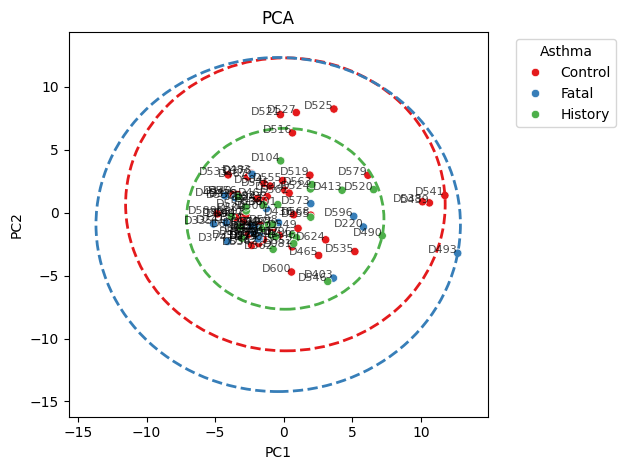

In [7]:
palette = sns.color_palette('Set1', n_colors=X_df['Asthma'].nunique())
sex_categories = X_df['Asthma'].unique()
color_dict = dict(zip(sex_categories, palette))

# Create scatter plot with mapped colors
scatter = sns.scatterplot(x='PC1', y='PC2', data=X_df, hue='Asthma', palette=color_dict)

# Annotate each point with its 'donor' value
for i, row in X_df.iterrows():
    plt.text(row['PC1'], row['PC2'], str(row['donor']), fontsize=8, ha='right', alpha=0.7)

# Compute centroids and plot circles
all_x, all_y = [], []  # Store all points for axis limit adjustment
for sex_group in sex_categories:
    subset = X_df[X_df['Asthma'] == sex_group]
    if not subset.empty:
        # Compute centroid
        centroid_x, centroid_y = subset[['PC1', 'PC2']].mean()
        
        # Compute max Euclidean distance for circle radius
        max_distance = np.max(np.sqrt((subset['PC1'] - centroid_x) ** 2 + (subset['PC2'] - centroid_y) ** 2))
        
        # Draw a circle with the same color as the points
        circle = plt.Circle((centroid_x, centroid_y), max_distance, color=color_dict[sex_group], fill=False, linestyle='--', linewidth=2)
        plt.gca().add_patch(circle)

        # Store values to adjust axis limits
        all_x.extend(subset['PC1'])
        all_y.extend(subset['PC2'])
        all_x.append(centroid_x + max_distance)
        all_x.append(centroid_x - max_distance)
        all_y.append(centroid_y + max_distance)
        all_y.append(centroid_y - max_distance)

# Labels and title
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA')

# Expand axis limits to fit the circles
plt.xlim(min(all_x) - 2, max(all_x) + 2)
plt.ylim(min(all_y) - 2, max(all_y) + 2)

# Adjust legend positioning
plt.legend(title='Asthma', bbox_to_anchor=(1.05, 1), loc='upper left')

# Final layout adjustment
plt.tight_layout()
plt.show()

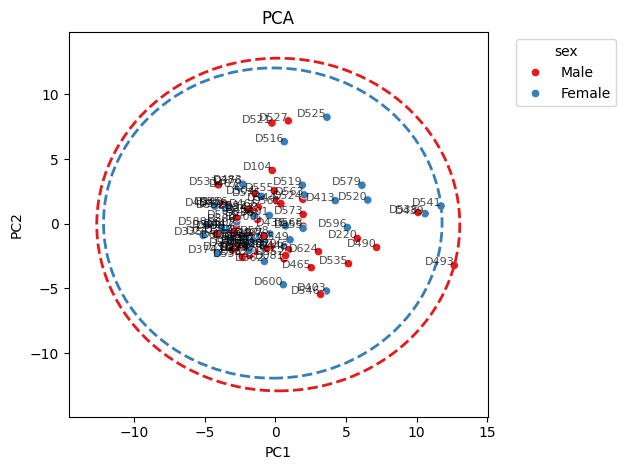

In [8]:
palette = sns.color_palette('Set1', n_colors=X_df['sex'].nunique())
sex_categories = X_df['sex'].unique()
color_dict = dict(zip(sex_categories, palette))

# Create scatter plot with mapped colors
scatter = sns.scatterplot(x='PC1', y='PC2', data=X_df, hue='sex', palette=color_dict)

# Annotate each point with its 'donor' value
for i, row in X_df.iterrows():
    plt.text(row['PC1'], row['PC2'], str(row['donor']), fontsize=8, ha='right', alpha=0.7)

# Compute centroids and plot circles
all_x, all_y = [], []  # Store all points for axis limit adjustment
for sex_group in sex_categories:
    subset = X_df[X_df['sex'] == sex_group]
    if not subset.empty:
        # Compute centroid
        centroid_x, centroid_y = subset[['PC1', 'PC2']].mean()
        
        # Compute max Euclidean distance for circle radius
        max_distance = np.max(np.sqrt((subset['PC1'] - centroid_x) ** 2 + (subset['PC2'] - centroid_y) ** 2))
        
        # Draw a circle with the same color as the points
        circle = plt.Circle((centroid_x, centroid_y), max_distance, color=color_dict[sex_group], fill=False, linestyle='--', linewidth=2)
        plt.gca().add_patch(circle)

        # Store values to adjust axis limits
        all_x.extend(subset['PC1'])
        all_y.extend(subset['PC2'])
        all_x.append(centroid_x + max_distance)
        all_x.append(centroid_x - max_distance)
        all_y.append(centroid_y + max_distance)
        all_y.append(centroid_y - max_distance)

# Labels and title
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA')

# Expand axis limits to fit the circles
plt.xlim(min(all_x) - 2, max(all_x) + 2)
plt.ylim(min(all_y) - 2, max(all_y) + 2)

# Adjust legend positioning
plt.legend(title='sex', bbox_to_anchor=(1.05, 1), loc='upper left')

# Final layout adjustment
plt.tight_layout()
plt.show()

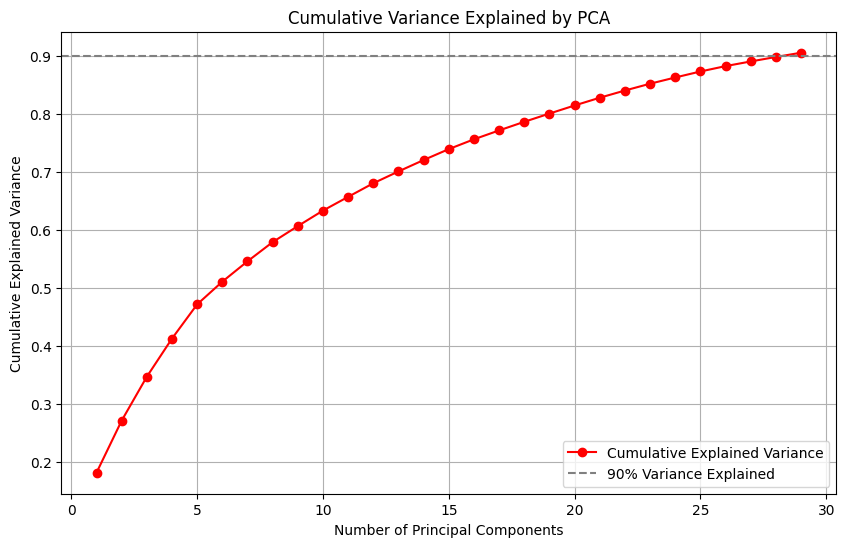

In [9]:
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(10, 6))
plt.plot(np.arange(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='-', color='r', label='Cumulative Explained Variance')
plt.axhline(y=0.9, color='gray', linestyle='--', label='90% Variance Explained')  # 90% threshold line
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Variance Explained by PCA")
plt.grid(True)
plt.legend()
plt.show()


In [10]:
features = df.drop(['Asthma', 'donor', 'sex'], axis=1).columns
pca_loadings = pd.DataFrame(pca.components_, columns=features, index=[f'PC{i+1}' for i in range(pca.n_components_)])
top_5_features = pca_loadings.abs().apply(lambda x: x.nlargest(5).index.tolist(), axis=1)
print(top_5_features)

PC1                   [IL-33, TPO, IL-9, LIF, TSLP]
PC2              [TNFa, IL-1RA, I-309, M-CSF, IL-6]
PC3            [TNFb, IL-22, VEGF-A, PDGF-AA, IL-5]
PC4       [IL-2, IL-1b, IL-1a, IL-17E_IL-25, IFNa2]
PC5         [PDGF-AB_BB, TNFb, IL-22, IL-7, MIP-1a]
PC6             [TGFa, CTACK, MCP-3, 6CKine, IL-1b]
PC7              [TRAIL, age, IL-7, IL-3, IL-12p70]
PC8         [IL-15, Eotaxin-2, RANTES, M-CSF, IL-5]
PC9            [IL-27, Eotaxin, G-CSF, IL-5, MCP-1]
PC10     [IP-10, SDF-1a+b, IL-15, BCA-1, Eotaxin-2]
PC11           [IL-15, IL-10, age, IL-12p40, IL-18]
PC12              [G-CSF, TRAIL, IL-6, IL-3, IL-27]
PC13          [SDF-1a+b, BCA-1, ENA-78, BMI, CTACK]
PC14               [TARC, Eotaxin, BMI, EGF, FGF-2]
PC15       [MIP-1d, FLT-3L, RANTES, IL-3, SDF-1a+b]
PC16           [IL-18, FGF-2, BCA-1, MIP-1b, IL-27]
PC17           [GM-CSF, BCA-1, GROa, RANTES, IL-18]
PC18               [age, BMI, Eotaxin, TARC, G-CSF]
PC19                [TRAIL, EGF, IL-18, CTACK, BMI]
PC20        

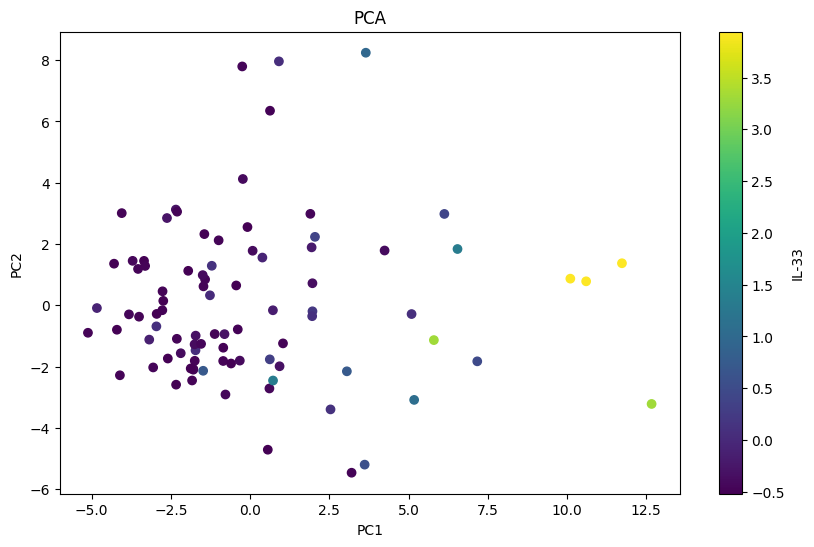

In [11]:
plt.figure(figsize=(10,6))
plt.scatter(X[:, 0], X[:, 1], c=df['IL-33'], cmap='viridis')
plt.colorbar(label='IL-33')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA')
plt.show()

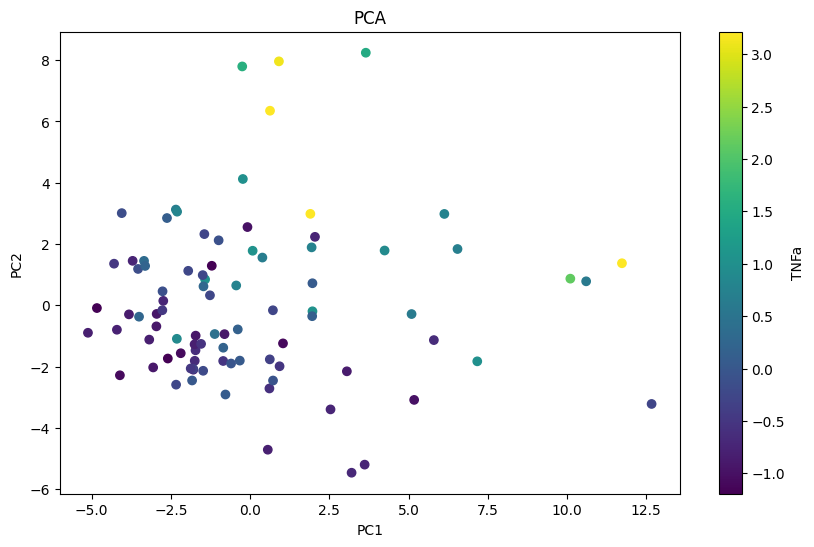

In [12]:
plt.figure(figsize=(10,6))
plt.scatter(X[:, 0], X[:, 1], c=df['TNFa'], cmap='viridis')
plt.colorbar(label='TNFa')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA')
plt.show()

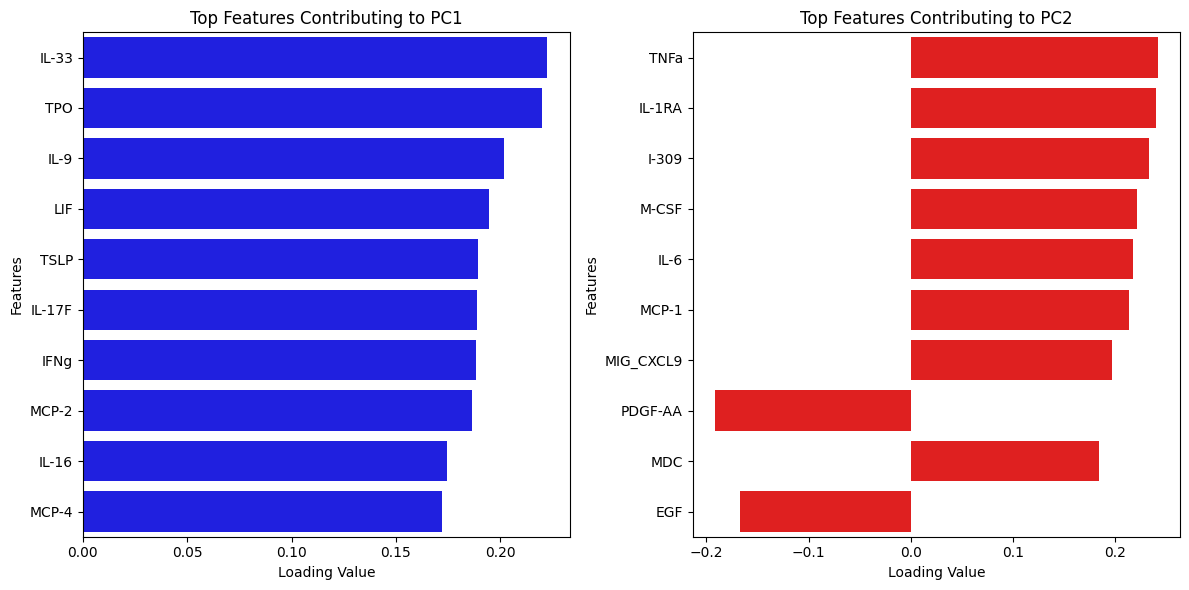

In [13]:
# Extract PC1 and PC2 loadings
pc1_loadings = pca_loadings.loc["PC1"].sort_values(key=abs, ascending=False)
pc2_loadings = pca_loadings.loc["PC2"].sort_values(key=abs, ascending=False)

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# PC1 plot
sns.barplot(x=pc1_loadings.values[:10], y=pc1_loadings.index[:10], ax=axes[0], color='blue')
axes[0].set_title("Top Features Contributing to PC1")
axes[0].set_xlabel("Loading Value")
axes[0].set_ylabel("Features")

# PC2 plot
sns.barplot(x=pc2_loadings.values[:10], y=pc2_loadings.index[:10], ax=axes[1], color='red')
axes[1].set_title("Top Features Contributing to PC2")
axes[1].set_xlabel("Loading Value")
axes[1].set_ylabel("Features")

plt.tight_layout()
plt.show()


## ctr

In [14]:
X_c = control.drop(['Asthma', 'donor', 'sex'], axis=1)
X_c = pca.fit_transform(X_c)

pca_columns = [f'PC{i+1}' for i in range(X_c.shape[1])]
X_c_df= pd.DataFrame(X_c, columns=pca_columns)

X_c_df = pd.concat([X_c_df, control[['Asthma', 'donor','sex']]], axis=1)
X_c_df['sex'] = X_c_df['sex'].apply(lambda x: 'Male' if x == 0 else 'Female')

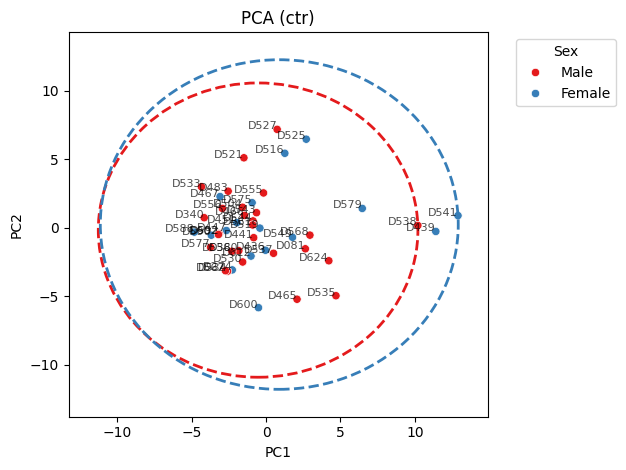

In [15]:
palette = sns.color_palette('Set1', n_colors=X_c_df['sex'].nunique())
sex_categories = X_c_df['sex'].unique()
color_dict = dict(zip(sex_categories, palette))

# Create scatter plot with mapped colors
scatter = sns.scatterplot(x='PC1', y='PC2', data=X_c_df, hue='sex', palette=color_dict)

# Annotate each point with its 'donor' value
for i, row in X_c_df.iterrows():
    plt.text(row['PC1'], row['PC2'], str(row['donor']), fontsize=8, ha='right', alpha=0.7)

# Compute centroids and plot circles
all_x, all_y = [], []  # Store all points for axis limit adjustment
for sex_group in sex_categories:
    subset = X_c_df[X_c_df['sex'] == sex_group]
    if not subset.empty:
        # Compute centroid
        centroid_x, centroid_y = subset[['PC1', 'PC2']].mean()
        
        # Compute max Euclidean distance for circle radius
        max_distance = np.max(np.sqrt((subset['PC1'] - centroid_x) ** 2 + (subset['PC2'] - centroid_y) ** 2))
        
        # Draw a circle with the same color as the points
        circle = plt.Circle((centroid_x, centroid_y), max_distance, color=color_dict[sex_group], fill=False, linestyle='--', linewidth=2)
        plt.gca().add_patch(circle)

        # Store values to adjust axis limits
        all_x.extend(subset['PC1'])
        all_y.extend(subset['PC2'])
        all_x.append(centroid_x + max_distance)
        all_x.append(centroid_x - max_distance)
        all_y.append(centroid_y + max_distance)
        all_y.append(centroid_y - max_distance)

# Labels and title
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA (ctr)')

# Expand axis limits to fit the circles
plt.xlim(min(all_x) - 2, max(all_x) + 2)
plt.ylim(min(all_y) - 2, max(all_y) + 2)

# Adjust legend positioning
plt.legend(title='Sex', bbox_to_anchor=(1.05, 1), loc='upper left')

# Final layout adjustment
plt.tight_layout()
plt.show()

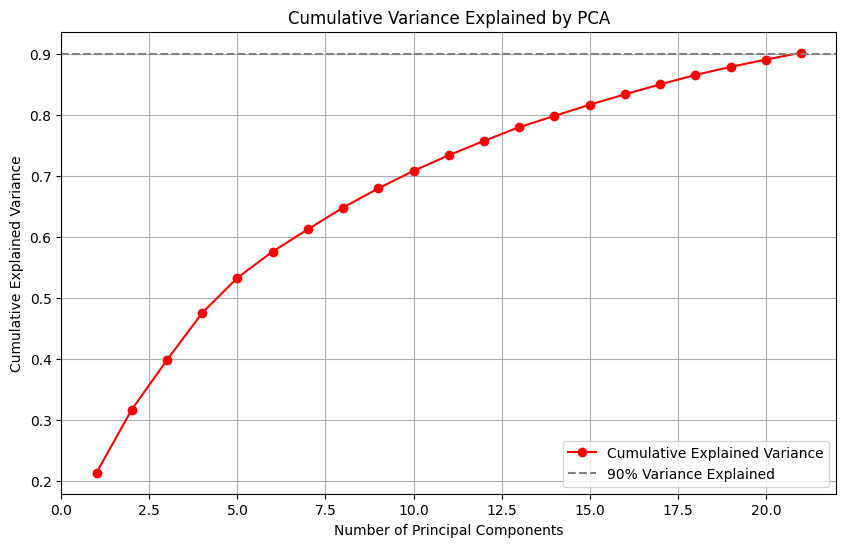

In [16]:
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(10, 6))
plt.plot(np.arange(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='-', color='r', label='Cumulative Explained Variance')
plt.axhline(y=0.9, color='gray', linestyle='--', label='90% Variance Explained')  # 90% threshold line
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Variance Explained by PCA")
plt.grid(True)
plt.legend()
plt.show()

In [17]:
features = control.drop(['Asthma', 'donor', 'sex'], axis=1).columns
pca_loadings = pd.DataFrame(pca.components_, columns=features, index=[f'PC{i+1}' for i in range(pca.n_components_)])
top_5_features = pca_loadings.abs().apply(lambda x: x.nlargest(5).index.tolist(), axis=1)
print(top_5_features)

PC1                 [IL-33, LIF, TPO, IFNg, TSLP]
PC2       [PDGF-AA, IL-1RA, M-CSF, sCD40L, MCP-1]
PC3          [GROa, VEGF-A, IL-5, I-309, PDGF-AA]
PC4          [MIP-1b, IL-8, 6CKine, TNFb, IL-17A]
PC5        [IL-15, IL-7, IL-20, MCP-2, Eotaxin-3]
PC6       [SDF-1a+b, MIP-1d, TNFb, 6CKine, BCA-1]
PC7      [Eotaxin-2, RANTES, sCD40L, IL-27, TGFa]
PC8      [IL-1a, IL-27, Eotaxin-2, TRAIL, 6CKine]
PC9     [Eotaxin, IL-18, IL-12p40, G-CSF, IL-28A]
PC10        [IL-10, RANTES, IP-10, IL-18, GM-CSF]
PC11        [MIP-1d, MCP-4, IL-20, Eotaxin, IL-5]
PC12             [IL-27, IL-18, IL-1b, IL-6, EGF]
PC13        [BCA-1, IL-13, MCP-2, Eotaxin, FGF-2]
PC14      [Fractalkine, age, TRAIL, IL-18, IL-1b]
PC15      [IL-16, CTACK, GROa, Eotaxin, SDF-1a+b]
PC16          [TRAIL, BMI, GM-CSF, IL-12p40, MDC]
PC17           [TARC, IL-15, MIP-1a, CTACK, IL-9]
PC18           [IL-1a, EGF, RANTES, IL-6, GM-CSF]
PC19          [Eotaxin-2, age, IFNa2, BCA-1, BMI]
PC20         [IL-3, SDF-1a+b, MIP-1a, IL-1b, BMI]


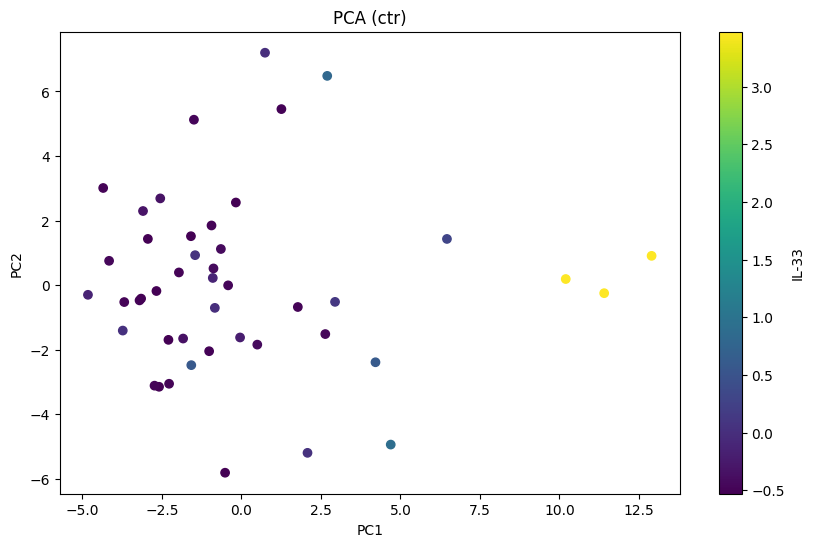

In [18]:
plt.figure(figsize=(10,6))
plt.scatter(X_c[:, 0], X_c[:, 1], c=control['IL-33'], cmap='viridis')
plt.colorbar(label='IL-33')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA (ctr)')
plt.show()

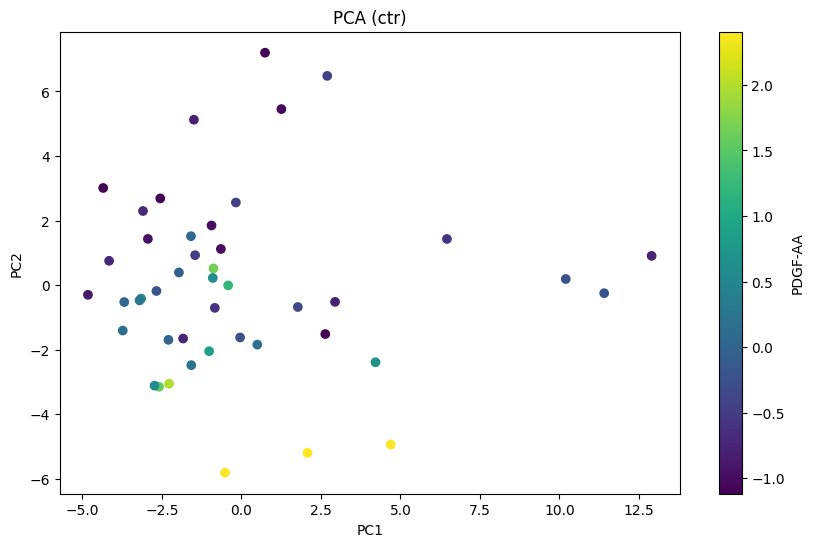

In [19]:
plt.figure(figsize=(10,6))
plt.scatter(X_c[:, 0], X_c[:, 1], c=control['PDGF-AA'], cmap='viridis')
plt.colorbar(label='PDGF-AA')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA (ctr)')
plt.show()

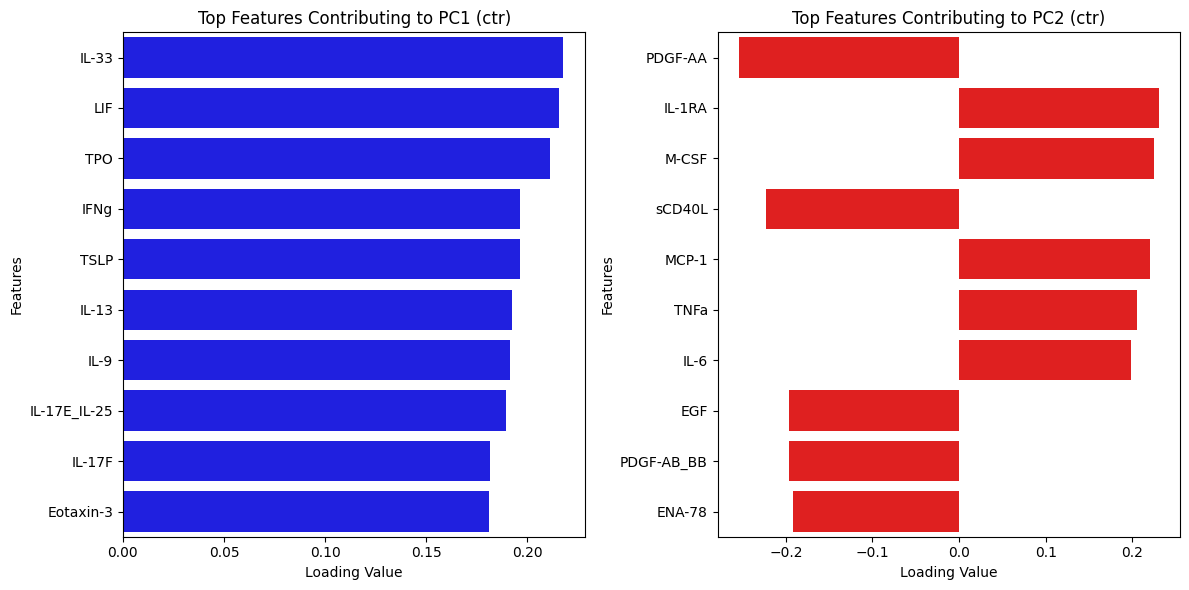

In [20]:
# Extract PC1 and PC2 loadings
pc1_loadings = pca_loadings.loc["PC1"].sort_values(key=abs, ascending=False)
pc2_loadings = pca_loadings.loc["PC2"].sort_values(key=abs, ascending=False)

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# PC1 plot
sns.barplot(x=pc1_loadings.values[:10], y=pc1_loadings.index[:10], ax=axes[0], color='blue')
axes[0].set_title("Top Features Contributing to PC1 (ctr)")
axes[0].set_xlabel("Loading Value")
axes[0].set_ylabel("Features")

# PC2 plot
sns.barplot(x=pc2_loadings.values[:10], y=pc2_loadings.index[:10], ax=axes[1], color='red')
axes[1].set_title("Top Features Contributing to PC2 (ctr)")
axes[1].set_xlabel("Loading Value")
axes[1].set_ylabel("Features")

plt.tight_layout()
plt.show()


## hst

In [21]:
history = history.reset_index(drop=True)

In [22]:
X_h = history.drop(['Asthma', 'donor', 'sex'], axis=1)
X_h = pca.fit_transform(X_h)

pca_columns = [f'PC{i+1}' for i in range(X_h.shape[1])]
X_h_df= pd.DataFrame(X_h, columns=pca_columns)

X_h_df = pd.concat([X_h_df, history[['Asthma', 'donor','sex']]], axis=1)

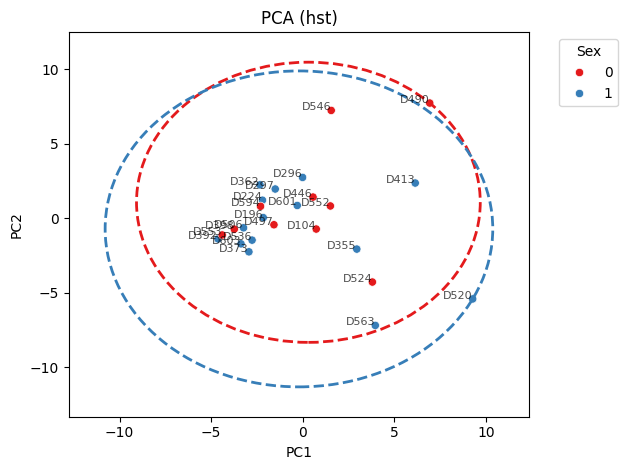

In [23]:
palette = sns.color_palette('Set1', n_colors=X_h_df['sex'].nunique())
sex_categories = X_h_df['sex'].unique()
color_dict = dict(zip(sex_categories, palette))

# Create scatter plot with mapped colors
scatter = sns.scatterplot(x='PC1', y='PC2', data=X_h_df, hue='sex', palette=color_dict)

# Annotate each point with its 'donor' value
for i, row in X_h_df.iterrows():
    plt.text(row['PC1'], row['PC2'], str(row['donor']), fontsize=8, ha='right', alpha=0.7)

# Compute centroids and plot circles
all_x, all_y = [], []  # Store all points for axis limit adjustment
for sex_group in sex_categories:
    subset = X_h_df[X_h_df['sex'] == sex_group]
    if not subset.empty:
        # Compute centroid
        centroid_x, centroid_y = subset[['PC1', 'PC2']].mean()
        
        # Compute max Euclidean distance for circle radius
        max_distance = np.max(np.sqrt((subset['PC1'] - centroid_x) ** 2 + (subset['PC2'] - centroid_y) ** 2))
        
        # Draw a circle with the same color as the points
        circle = plt.Circle((centroid_x, centroid_y), max_distance, color=color_dict[sex_group], fill=False, linestyle='--', linewidth=2)
        plt.gca().add_patch(circle)

        # Store values to adjust axis limits
        all_x.extend(subset['PC1'])
        all_y.extend(subset['PC2'])
        all_x.append(centroid_x + max_distance)
        all_x.append(centroid_x - max_distance)
        all_y.append(centroid_y + max_distance)
        all_y.append(centroid_y - max_distance)

# Labels and title
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA (hst)')

# Expand axis limits to fit the circles
plt.xlim(min(all_x) - 2, max(all_x) + 2)
plt.ylim(min(all_y) - 2, max(all_y) + 2)

# Adjust legend positioning
plt.legend(title='Sex', bbox_to_anchor=(1.05, 1), loc='upper left')

# Final layout adjustment
plt.tight_layout()
plt.show()

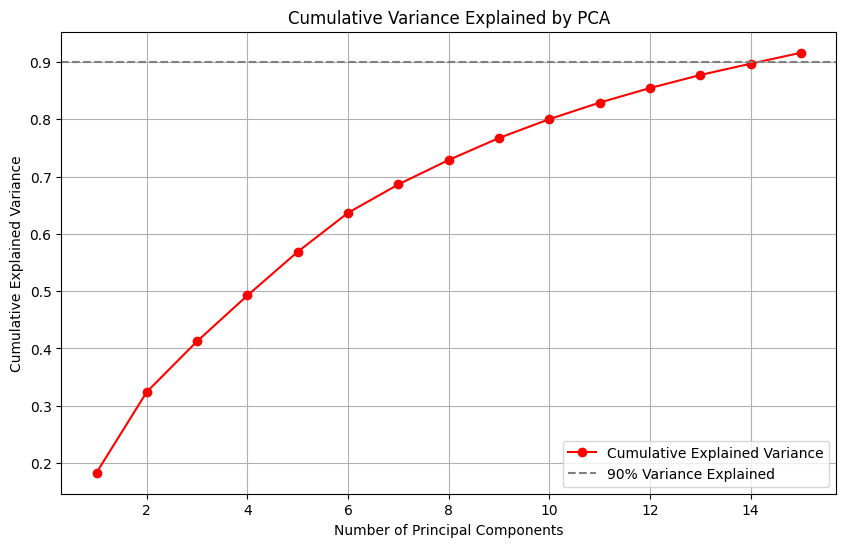

In [24]:
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(10, 6))
plt.plot(np.arange(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='-', color='r', label='Cumulative Explained Variance')
plt.axhline(y=0.9, color='gray', linestyle='--', label='90% Variance Explained')  # 90% threshold line
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Variance Explained by PCA")
plt.grid(True)
plt.legend()
plt.show()

In [25]:
features = history.drop(['Asthma', 'donor', 'sex'], axis=1).columns
pca_loadings = pd.DataFrame(pca.components_, columns=features, index=[f'PC{i+1}' for i in range(pca.n_components_)])
top_5_features = pca_loadings.abs().apply(lambda x: x.nlargest(5).index.tolist(), axis=1)
print(top_5_features)

PC1                 [MCP-2, MCP-4, IL-20, TPO, G-CSF]
PC2                  [IL-1b, IL-1a, IL-2, IFNa2, SCF]
PC3             [GROa, TGFa, EGF, Fractalkine, MCP-3]
PC4                  [age, MIP-1a, IL-22, IL-7, IL-5]
PC5               [M-CSF, FGF-2, IL-6, MCP-1, RANTES]
PC6       [MIG_CXCL9, PDGF-AB_BB, TNFb, IL-8, GM-CSF]
PC7     [IL-12p40, TARC, Fractalkine, Eotaxin-2, TPO]
PC8          [SDF-1a+b, IL-28A, IL-16, RANTES, IL-18]
PC9          [Eotaxin-2, VEGF-A, GM-CSF, IFNg, IP-10]
PC10                   [BCA-1, TRAIL, IL-8, age, LIF]
PC11            [Eotaxin, sCD40L, IL-3, IL-9, VEGF-A]
PC12               [BMI, ENA-78, IL-3, IL-27, MIP-1b]
PC13             [MIP-1b, IL-18, BMI, GM-CSF, 6CKine]
PC14        [PDGF-AB_BB, GM-CSF, IL-15, ENA-78, IL-3]
PC15             [VEGF-A, FLT-3L, TRAIL, CTACK, TARC]
dtype: object


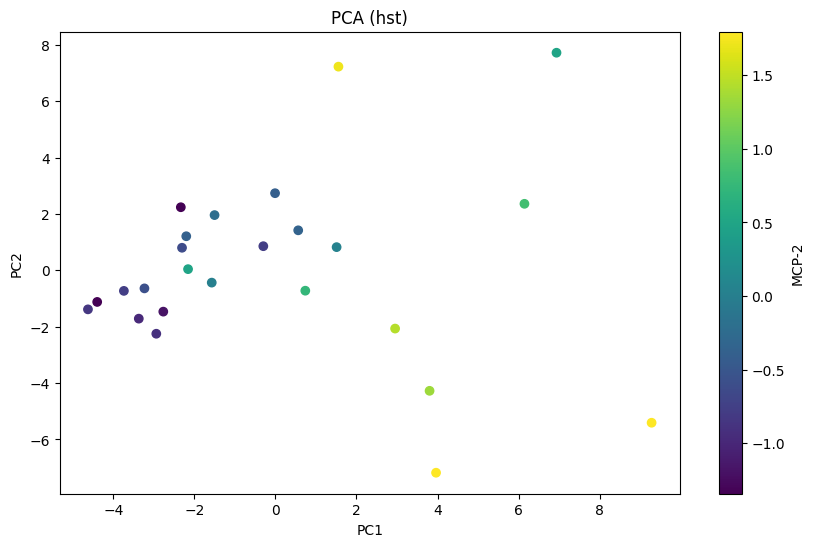

In [26]:
plt.figure(figsize=(10,6))
plt.scatter(X_h[:, 0], X_h[:, 1], c=history['MCP-2'], cmap='viridis')
plt.colorbar(label='MCP-2')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA (hst)')
plt.show()

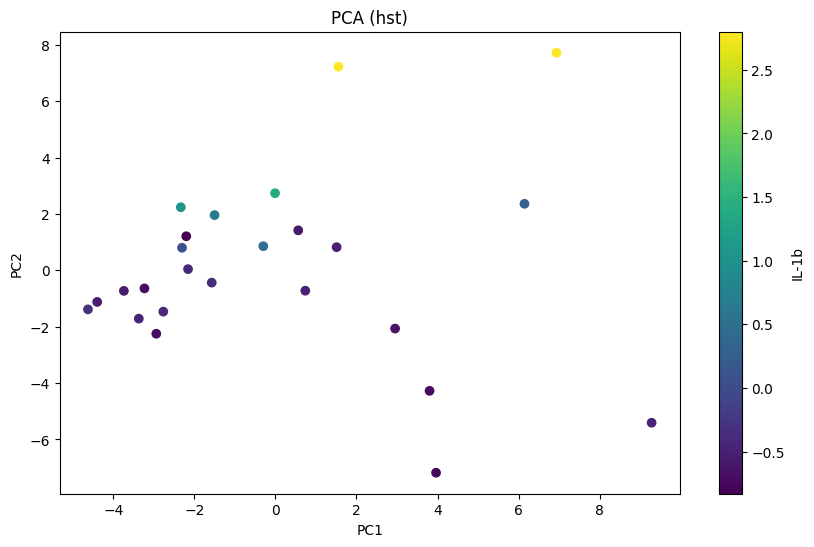

In [27]:
plt.figure(figsize=(10,6))
plt.scatter(X_h[:, 0], X_h[:, 1], c=history['IL-1b'], cmap='viridis')
plt.colorbar(label='IL-1b')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA (hst)')
plt.show()

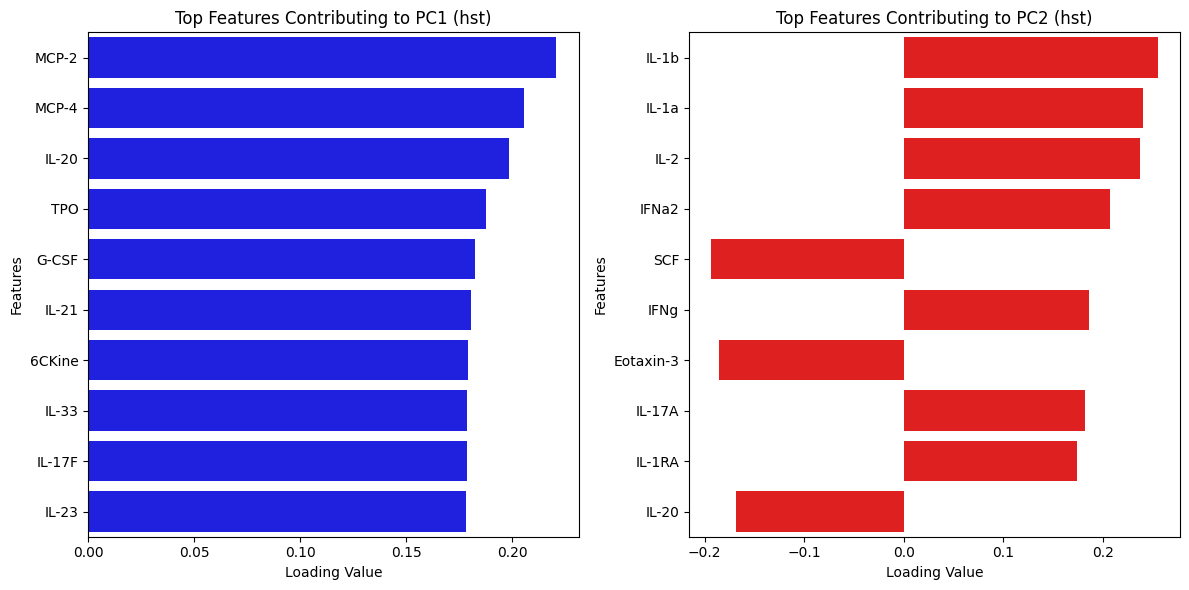

In [28]:
# Extract PC1 and PC2 loadings
pc1_loadings = pca_loadings.loc["PC1"].sort_values(key=abs, ascending=False)
pc2_loadings = pca_loadings.loc["PC2"].sort_values(key=abs, ascending=False)

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# PC1 plot
sns.barplot(x=pc1_loadings.values[:10], y=pc1_loadings.index[:10], ax=axes[0], color='blue')
axes[0].set_title("Top Features Contributing to PC1 (hst)")
axes[0].set_xlabel("Loading Value")
axes[0].set_ylabel("Features")

# PC2 plot
sns.barplot(x=pc2_loadings.values[:10], y=pc2_loadings.index[:10], ax=axes[1], color='red')
axes[1].set_title("Top Features Contributing to PC2 (hst)")
axes[1].set_xlabel("Loading Value")
axes[1].set_ylabel("Features")

plt.tight_layout()
plt.show()

## fatal

In [29]:
fatal = fatal.reset_index(drop=True)
fatal

,donor,Asthma,sex,age,BMI,EGF,Eotaxin,FGF-2,FLT-3L,Fractalkine,...,LIF,MCP-2,MCP-4,MIP-1d,SCF,SDF-1a+b,TARC,TPO,TRAIL,TSLP
0,D220,Fatal,0,1.594708,1.115640,2.257685,-0.455895,-0.098345,-0.006347,-0.649777,...,1.047404,1.671218,1.620064,-0.562308,-0.113641,-1.028315,0.395931,2.858297,0.172543,2.731069
1,D241,Fatal,0,-1.205036,-0.637509,-0.198763,-0.439052,-1.397538,-0.692242,-0.737551,...,-0.440637,-0.417008,-0.319064,-0.263961,-0.055302,0.995127,-0.820849,-0.403572,0.092168,-0.649457
2,D335,Fatal,1,-0.956170,-1.275017,-0.750670,-0.932400,-1.273969,-0.935320,-0.449641,...,-0.649074,-0.937551,-0.824413,-1.348883,-0.540160,0.128459,-0.861694,-0.487400,0.207673,-0.346558
3,D359,Fatal,1,-0.022922,-1.275017,0.370121,-0.502212,0.530136,-0.194780,-0.831757,...,-0.732263,-0.532012,-0.860649,0.734153,-0.445846,2.580629,1.818911,-0.258452,-0.952697,-0.588321
4,D374,Fatal,1,1.470275,0.318754,1.313097,0.080261,-1.397538,-0.183474,-0.566776,...,-0.815451,-0.937551,-0.969358,0.143441,-0.540160,0.329170,-0.188413,-0.411150,0.397697,-0.634173
5,D376,Fatal,1,-0.645087,-1.275017,-1.090687,2.133653,-0.601067,2.271803,-0.133615,...,-0.899574,1.071988,1.411461,0.257915,0.022158,0.201004,-0.645611,-0.429067,2.723760,-0.346558
6,D403,Fatal,1,-1.267253,2.550034,0.601714,-1.071351,1.751121,0.666357,-0.881972,...,-0.023761,0.565063,1.012862,-0.647627,-0.354773,-1.256954,-0.899245,0.267056,-0.391674,0.405134
7,D450,Fatal,1,2.030224,0.159377,2.421498,-0.865029,0.084975,-0.194780,-0.607758,...,0.018300,1.250546,1.471201,-0.562777,-0.615676,-0.781323,-0.138345,-0.477338,-0.670056,-0.668909
8,D454,Fatal,1,-0.707304,0.000000,-0.817335,1.071166,-0.689442,-0.731813,2.205351,...,-0.649074,-0.571355,-0.824413,-1.348883,-0.540160,-1.080227,-1.123891,-0.453722,-0.952697,-0.346558
9,D461,Fatal,1,-1.018387,-0.159377,0.248563,-0.149921,0.833427,-0.315377,-0.881972,...,-0.899574,-0.417008,-0.969358,-1.107797,-0.558958,-1.035118,-0.836660,-0.263073,-0.280960,-0.429924


In [30]:
X_f = fatal.drop(['Asthma', 'donor', 'sex'], axis=1)
X_f = pca.fit_transform(X_f)

pca_columns = [f'PC{i+1}' for i in range(X_f.shape[1])]
X_f_df= pd.DataFrame(X_f, columns=pca_columns)

X_f_df = pd.concat([X_f_df, fatal[['Asthma', 'donor','sex']]], axis=1)

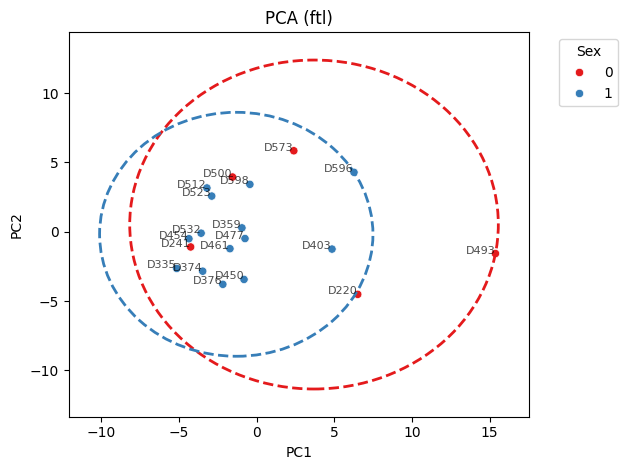

In [31]:
palette = sns.color_palette('Set1', n_colors=X_f_df['sex'].nunique())
sex_categories = X_f_df['sex'].unique()
color_dict = dict(zip(sex_categories, palette))

# Create scatter plot with mapped colors
scatter = sns.scatterplot(x='PC1', y='PC2', data=X_f_df, hue='sex', palette=color_dict)

# Annotate each point with its 'donor' value
for i, row in X_f_df.iterrows():
    plt.text(row['PC1'], row['PC2'], str(row['donor']), fontsize=8, ha='right', alpha=0.7)

# Compute centroids and plot circles
all_x, all_y = [], []  # Store all points for axis limit adjustment
for sex_group in sex_categories:
    subset = X_f_df[X_f_df['sex'] == sex_group]
    if not subset.empty:
        # Compute centroid
        centroid_x, centroid_y = subset[['PC1', 'PC2']].mean()
        
        # Compute max Euclidean distance for circle radius
        max_distance = np.max(np.sqrt((subset['PC1'] - centroid_x) ** 2 + (subset['PC2'] - centroid_y) ** 2))
        
        # Draw a circle with the same color as the points
        circle = plt.Circle((centroid_x, centroid_y), max_distance, color=color_dict[sex_group], fill=False, linestyle='--', linewidth=2)
        plt.gca().add_patch(circle)

        # Store values to adjust axis limits
        all_x.extend(subset['PC1'])
        all_y.extend(subset['PC2'])
        all_x.append(centroid_x + max_distance)
        all_x.append(centroid_x - max_distance)
        all_y.append(centroid_y + max_distance)
        all_y.append(centroid_y - max_distance)

# Labels and title
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA (ftl)')

# Expand axis limits to fit the circles
plt.xlim(min(all_x) - 2, max(all_x) + 2)
plt.ylim(min(all_y) - 2, max(all_y) + 2)

# Adjust legend positioning
plt.legend(title='Sex', bbox_to_anchor=(1.05, 1), loc='upper left')

# Final layout adjustment
plt.tight_layout()
plt.show()

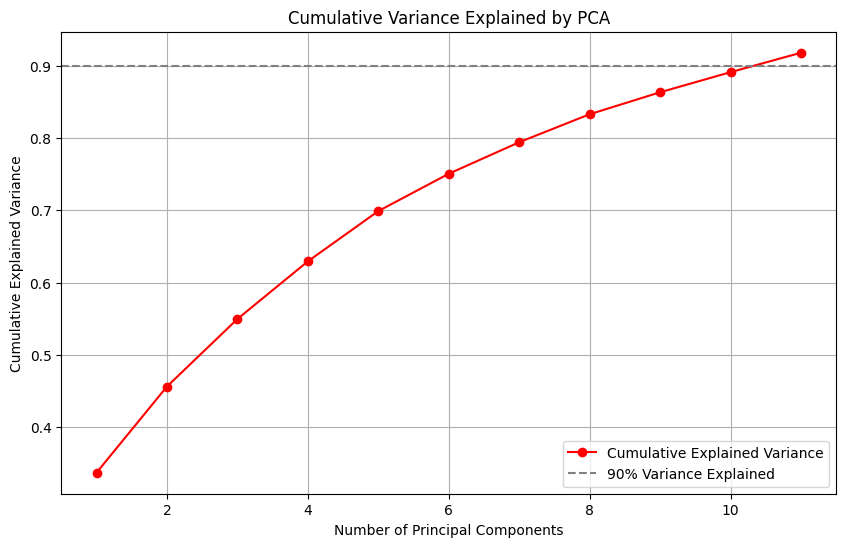

In [32]:
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(10, 6))
plt.plot(np.arange(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='-', color='r', label='Cumulative Explained Variance')
plt.axhline(y=0.9, color='gray', linestyle='--', label='90% Variance Explained')  # 90% threshold line
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Variance Explained by PCA")
plt.grid(True)
plt.legend()
plt.show()

In [33]:
features = fatal.drop(['Asthma', 'donor', 'sex'], axis=1).columns
pca_loadings = pd.DataFrame(pca.components_, columns=features, index=[f'PC{i+1}' for i in range(pca.n_components_)])
top_5_features = pca_loadings.abs().apply(lambda x: x.nlargest(5).index.tolist(), axis=1)
print(top_5_features)

PC1           [IL-28A, ENA-78, 6CKine, IL-20, LIF]
PC2           [TNFb, IL-22, MIP-1a, IL-13, IL-1RA]
PC3       [MCP-1, Eotaxin, MIP-1b, BMI, MIG_CXCL9]
PC4          [IL-3, IL-1a, CTACK, PDGF-AB_BB, age]
PC5              [IL-6, G-CSF, TRAIL, IL-5, IL-27]
PC6     [IL-15, IL-10, Fractalkine, RANTES, IL-21]
PC7            [IL-18, SDF-1a+b, CTACK, TARC, age]
PC8             [IL-8, MDC, GM-CSF, CTACK, IL-1RA]
PC9        [Eotaxin-2, MIP-1d, BMI, RANTES, G-CSF]
PC10     [age, SDF-1a+b, IP-10, IL-4, Fractalkine]
PC11        [M-CSF, MIG_CXCL9, IL-10, IL-6, MCP-3]
dtype: object


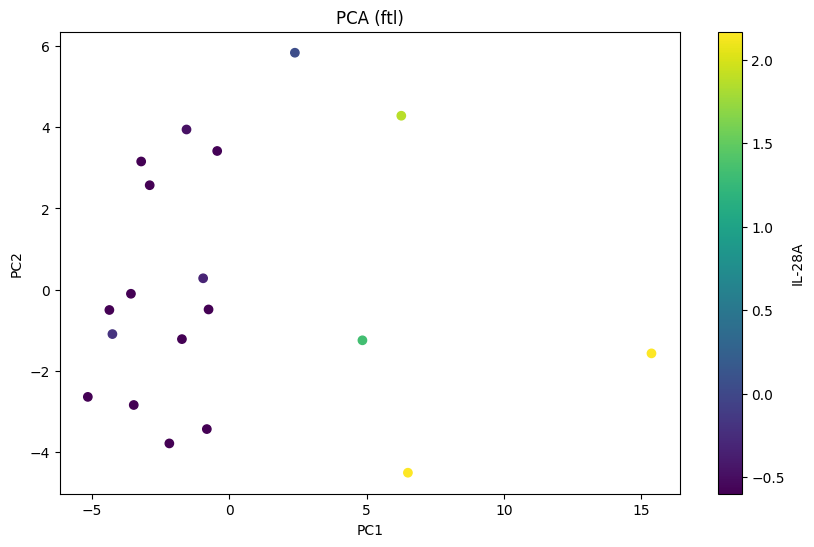

In [34]:
plt.figure(figsize=(10,6))
plt.scatter(X_f[:, 0], X_f[:, 1], c=fatal['IL-28A'], cmap='viridis')
plt.colorbar(label='IL-28A')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA (ftl)')
plt.show()

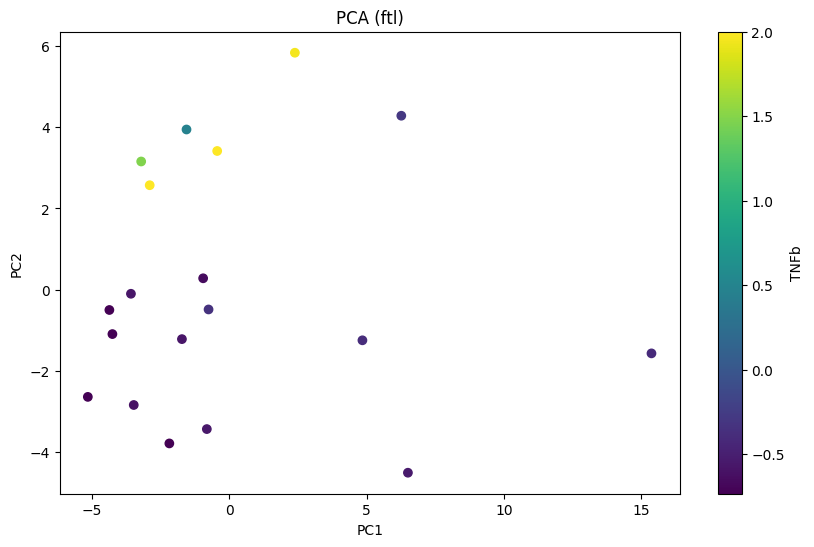

In [35]:
plt.figure(figsize=(10,6))
plt.scatter(X_f[:, 0], X_f[:, 1], c=fatal['TNFb'], cmap='viridis')
plt.colorbar(label='TNFb')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA (ftl)')
plt.show()

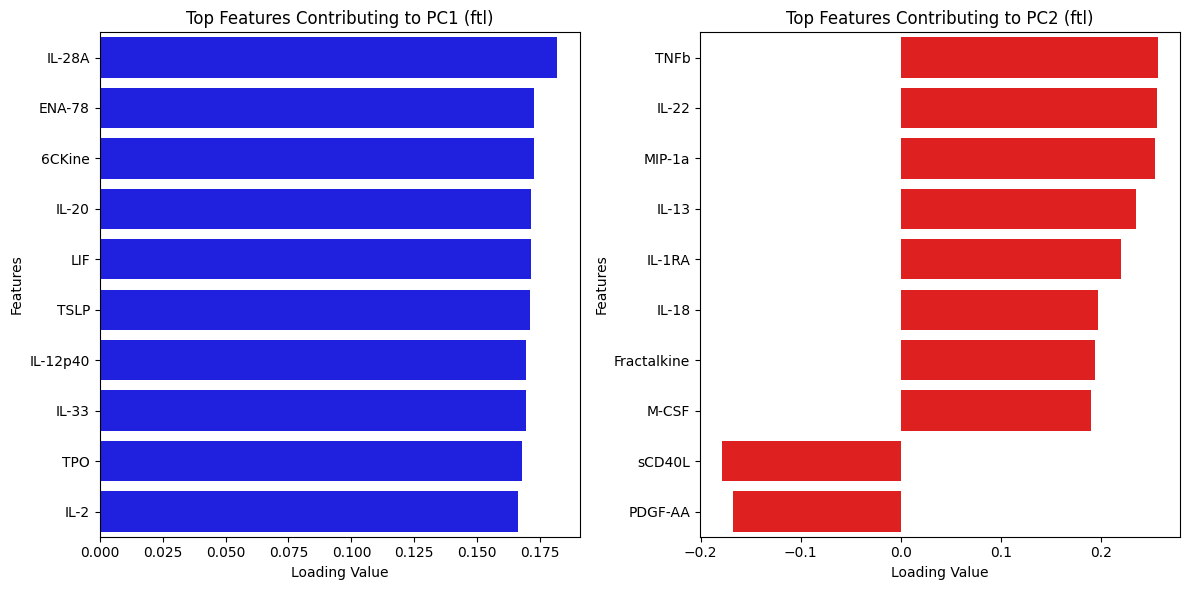

In [36]:
# Extract PC1 and PC2 loadings
pc1_loadings = pca_loadings.loc["PC1"].sort_values(key=abs, ascending=False)
pc2_loadings = pca_loadings.loc["PC2"].sort_values(key=abs, ascending=False)

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# PC1 plot
sns.barplot(x=pc1_loadings.values[:10], y=pc1_loadings.index[:10], ax=axes[0], color='blue')
axes[0].set_title("Top Features Contributing to PC1 (ftl)")
axes[0].set_xlabel("Loading Value")
axes[0].set_ylabel("Features")

# PC2 plot
sns.barplot(x=pc2_loadings.values[:10], y=pc2_loadings.index[:10], ax=axes[1], color='red')
axes[1].set_title("Top Features Contributing to PC2 (ftl)")
axes[1].set_xlabel("Loading Value")
axes[1].set_ylabel("Features")

plt.tight_layout()
plt.show()

## Model

In [37]:
df = df.drop('donor', axis = 1)
X = df.drop('Asthma', axis = 1)
X

,sex,age,BMI,EGF,Eotaxin,FGF-2,FLT-3L,Fractalkine,G-CSF,GM-CSF,...,LIF,MCP-2,MCP-4,MIP-1d,SCF,SDF-1a+b,TARC,TPO,TRAIL,TSLP
0,0,0.076173,0.283649,-0.625963,-1.177476,2.851592,-0.766117,1.310144,-0.561533,4.248608,...,-0.233520,-0.418742,0.443448,-1.397368,-0.696433,-1.461409,-1.108148,-0.652345,-0.914488,-0.566851
1,1,-1.744216,-0.826012,-0.716379,0.365412,1.390439,0.109159,-0.069532,-0.417212,-0.504806,...,-0.438303,1.213888,-0.453353,-1.234017,-0.696433,-0.172965,0.340675,-0.542457,1.177551,-0.396630
2,0,-1.179268,-0.548597,-0.571878,-1.245449,-0.767121,-0.506853,-0.168713,1.368629,-0.504806,...,-0.373980,-0.634350,-0.704254,-0.180593,-0.696433,1.787315,-0.870903,-0.569529,-0.743369,-0.462987
3,0,-1.618672,-1.519551,-0.120950,-0.885100,-0.782826,-0.921675,0.026945,-0.786295,-0.348257,...,-0.221706,0.600499,-0.204995,-1.296099,-0.675432,-0.621040,-0.841247,-0.383792,1.226692,-0.275456
4,1,1.268842,-0.271181,1.647582,-0.927001,-0.815330,-0.442555,-1.303291,-0.763712,-0.504806,...,0.022458,1.457168,1.935290,-0.511928,-0.071375,-0.627361,1.544121,-0.230330,-0.201054,-0.073500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84,0,1.143298,-0.964720,-0.529629,-0.058253,-0.896442,-0.674856,1.011397,-0.678323,-0.504806,...,-0.174974,-1.252351,-0.577956,-1.340080,-0.219809,-1.273856,-0.532732,-0.592090,0.008677,-0.396630
85,1,-0.739864,0.422357,-0.765039,0.430592,-0.312707,-0.836637,-0.168713,0.257291,-0.480931,...,1.275569,1.839960,3.505115,1.201172,1.690961,0.136416,0.348328,0.256567,0.556257,0.694897
86,0,-0.739864,0.422357,0.008591,0.938060,0.130177,-0.699745,0.632403,-0.521312,-0.504806,...,-0.139793,-0.549029,-0.328750,0.050955,-0.260743,-0.372142,-0.617873,-0.578298,0.162245,-0.614936
87,1,1.331614,-0.548597,-0.755011,-0.796642,-0.693116,-0.272478,0.258218,0.718430,0.258496,...,-0.368204,-0.694305,-0.704254,0.707566,0.017970,-0.138627,0.416249,-0.551596,-0.774083,-0.396630


In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, df['Asthma'], test_size=0.2, random_state=0)

In [39]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.model_selection import cross_val_score

model = RandomForestClassifier(n_estimators=100, random_state=0)
model.fit(X_train, y_train)

scores = cross_val_score(model, X, df['Asthma'], cv=5)
print("Cross-validation scores:", scores)
print("Mean cross-validation score:", scores.mean())

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Cross-validation scores: [0.66666667 0.5        0.61111111 0.61111111 0.41176471]
Mean cross-validation score: 0.5601307189542484
Accuracy: 0.5555555555555556


In [40]:
importances = model.feature_importances_
importances_df = pd.DataFrame({
    'feature': X.columns,
    'importance': importances
})
importances_df.sort_values(by='importance', ascending=False).head(10)


,feature,importance
72,TRAIL,0.044334
8,G-CSF,0.036322
22,IL-8,0.035921
13,IL-1a,0.027682
21,IL-7,0.026860
23,IL-9,0.024050
51,6CKine,0.023951
42,MIP-1b,0.023216
39,MDC,0.022789
19,IL-5,0.022778


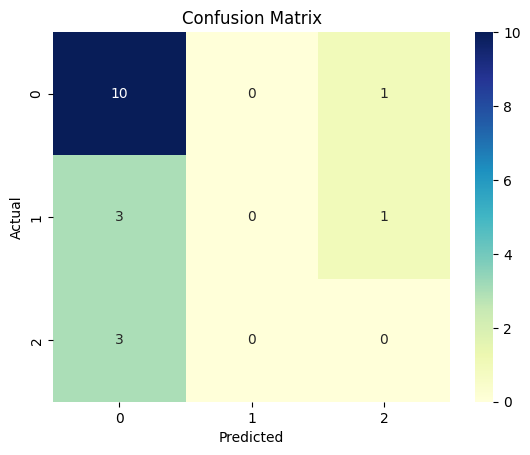

In [41]:
confusion_matrix(y_test, y_pred)
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='YlGnBu')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [42]:
from sklearn.svm import SVC

model_svm = SVC(kernel='linear')
model_svm.fit(X_train, y_train)

scores_svm = cross_val_score(model_svm, X, df['Asthma'], cv=5)
print("Cross-validation scores:", scores_svm)
print("Mean cross-validation score:", scores_svm.mean())

y_pred_svm = model_svm.predict(X_test)
accuracy_svm = accuracy_score(y_test, y_pred_svm)
print("Accuracy:", accuracy_svm)

Cross-validation scores: [0.61111111 0.66666667 0.44444444 0.61111111 0.52941176]
Mean cross-validation score: 0.5725490196078431
Accuracy: 0.4444444444444444


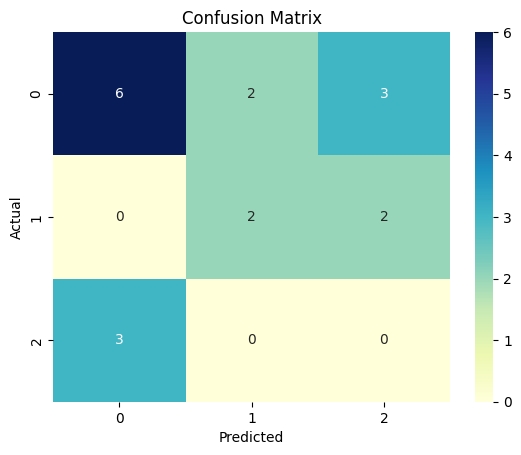

In [43]:
confusion_matrix_svm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(confusion_matrix_svm, annot=True, fmt='d', cmap='YlGnBu')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [44]:
#what about logistic regression
from sklearn.linear_model import LogisticRegression

model_lr = LogisticRegression()
model_lr.fit(X_train, y_train)

scores_lr = cross_val_score(model_lr, X, df['Asthma'], cv=5)
print("Cross-validation scores:", scores_lr)
print("Mean cross-validation score:", scores_lr.mean())

y_pred_lr = model_lr.predict(X_test)
accuracy_lr = accuracy_score(y_test, y_pred_lr)
print("Accuracy:", accuracy_lr)

Cross-validation scores: [0.72222222 0.66666667 0.5        0.55555556 0.47058824]
Mean cross-validation score: 0.5830065359477125
Accuracy: 0.4444444444444444


In [45]:
importances_lr = model_lr.coef_[0]
importances_lr_df = pd.DataFrame({
    'feature': X.columns,
    'importance': importances_lr
})
importances_lr_df.sort_values(by='importance', ascending=False).head(10)

,feature,importance
21,IL-7,0.690666
5,FGF-2,0.649575
22,IL-8,0.515230
39,MDC,0.452436
31,IL-17F,0.440792
40,MIG_CXCL9,0.393464
61,IL-23,0.378016
15,IL-1RA,0.327566
20,IL-6,0.306966
62,IL-28A,0.293641


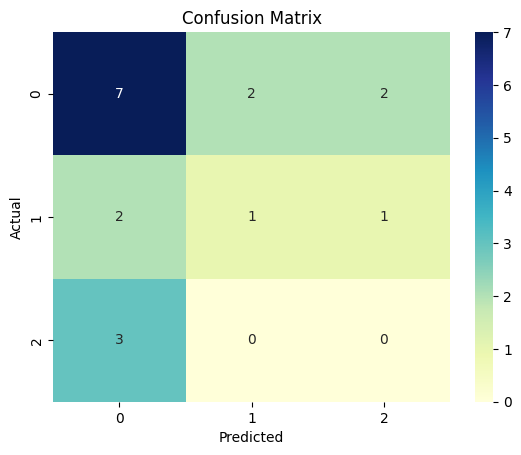

In [46]:
confusion_matrix_lr = confusion_matrix(y_test, y_pred_lr)
sns.heatmap(confusion_matrix_lr, annot=True, fmt='d', cmap='YlGnBu')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## clusters

In [47]:
import scanpy as sc
df = pd.read_excel('stat test_01APR25.xlsx')
df['sex'] = df['sex'].apply(lambda x: 0 if x == 'MALE' else 1)
#if Asthma == Control, set 0, if Asthma == History, set 1, if Asthma == fatal, set 2
df['Asthma'] = df['Asthma'].apply(lambda x: 2 if x == 'Fatal' else (1 if x == 'History' else 0))
df

,donor,Asthma,sex,age,BMI,EGF,Eotaxin,FGF-2,FLT-3L,Fractalkine,...,LIF,MCP-2,MCP-4,MIP-1d,SCF,SDF-1a+b,TARC,TPO,TRAIL,TSLP
0,D081,0,0,43,31,29.94,8.43,815.67,4.41,203.81,...,9.34,17.17,15.98,851.07,2.44,739.39,0.27,12.21,1.44,0.67
1,D274,0,1,14,23,24.44,25.00,521.68,8.63,112.00,...,1.54,31.33,5.40,1123.32,2.44,2371.99,30.56,98.18,25.28,2.44
2,D340,0,0,23,25,33.23,7.70,87.57,5.66,105.40,...,3.99,15.30,2.44,2879.01,2.44,4855.88,5.23,77.00,3.39,1.75
3,D360,0,0,16,18,60.66,11.57,84.41,3.66,118.42,...,9.79,26.01,8.33,1019.85,3.03,1804.23,5.85,222.31,25.84,3.70
4,D436,0,1,62,27,168.24,11.12,77.87,5.97,29.90,...,19.09,33.44,33.58,2326.79,20.00,1796.22,55.72,342.37,9.57,5.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84,D553,1,0,60,22,35.80,20.45,61.55,4.85,183.93,...,11.57,9.94,3.93,946.55,15.83,977.04,12.30,59.35,11.96,2.44
85,D563,1,1,30,32,21.48,25.70,179.00,4.07,105.40,...,66.82,36.76,52.10,5181.93,69.51,2764.01,30.72,723.29,18.20,13.79
86,D594,1,0,30,32,68.54,31.15,268.11,4.73,158.71,...,12.91,16.04,6.87,3264.92,14.68,2119.61,10.52,70.14,13.71,0.17
87,D601,1,1,63,25,22.09,12.52,102.46,6.79,133.81,...,4.21,14.78,2.44,4359.26,22.51,2415.50,32.14,91.03,3.04,2.44


In [48]:
df_numeric = df.select_dtypes(include=[np.number])
list_metadata = {'donor' : df.donor, 'Asthma' : df.Asthma, 'sex': df.sex}
df_metadata = pd.DataFrame(list_metadata)

In [49]:
adata = sc.AnnData(df_numeric)
df_metadata.index = adata.obs.index
adata.obs['donor'] = df_metadata.donor
adata.obs['Asthma'] = df_metadata.Asthma
adata.obs['sex'] = df_metadata.sex

/usr/local/lib/python3.11/site-packages/anndata/utils.py:304: UserWarning: X converted to numpy array with dtype float64
  warnings.warn(f"{name} converted to numpy array with dtype {arr.dtype}")
/usr/local/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [50]:
sc.pp.scale(adata, max_value=5)

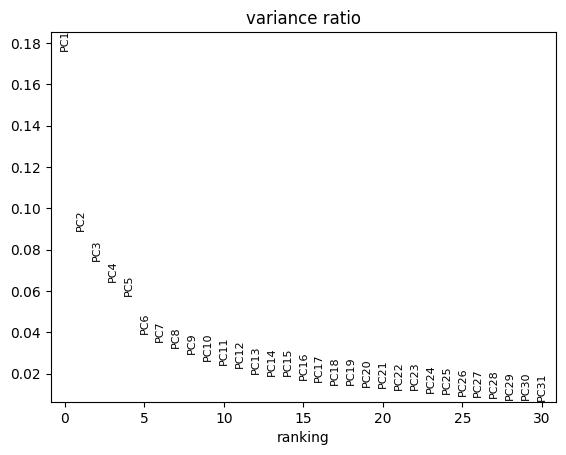

In [51]:
sc.tl.pca(adata, svd_solver="arpack")
sc.pl.pca_variance_ratio(adata, log=False)

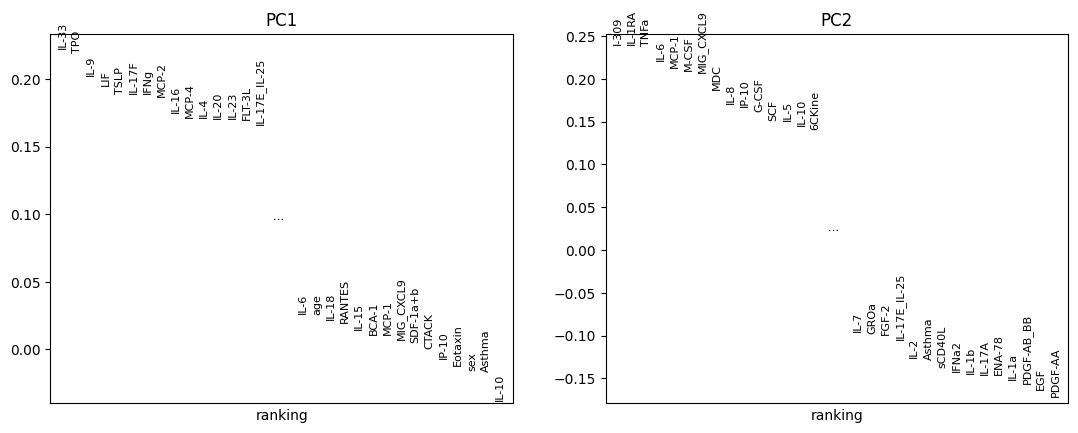

In [52]:
sc.pl.pca_loadings(adata, components = '1,2')

/var/folders/66/xf6391m10_1_0gt7tbm34_7r0000gn/T/ipykernel_17286/1861043294.py:2: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, resolution=0.8, flavor='leidenalg')


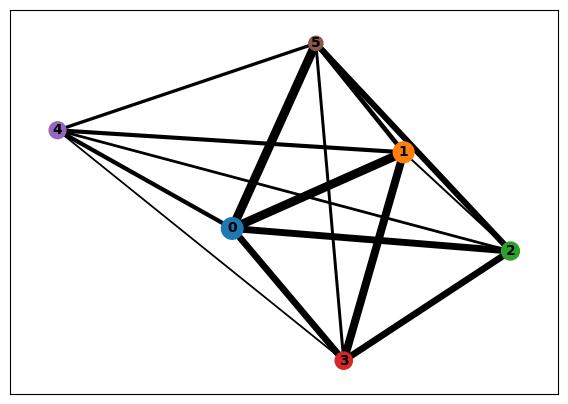

In [53]:
sc.pp.neighbors(adata, n_neighbors=15, n_pcs= 15, random_state=0)
sc.tl.leiden(adata, resolution=0.8, flavor='leidenalg')
sc.tl.paga(adata)
sc.pl.paga(adata)
sc.tl.umap(adata, init_pos='paga', random_state=0)

In [54]:
markers = list(adata.var_names)

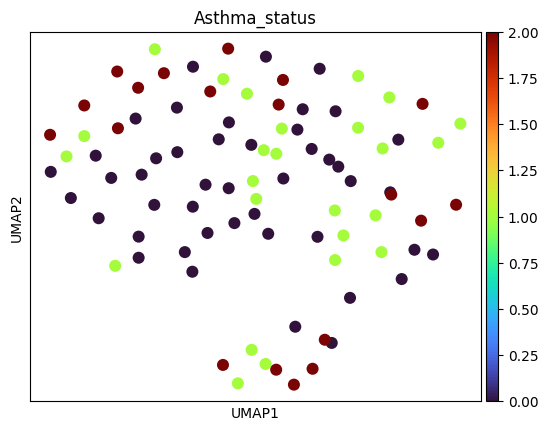

In [55]:
adata.obs.rename(columns={"Asthma": "Asthma_status"}, inplace=True)
sc.pl.umap(adata, color="Asthma_status", cmap='turbo', size=300)


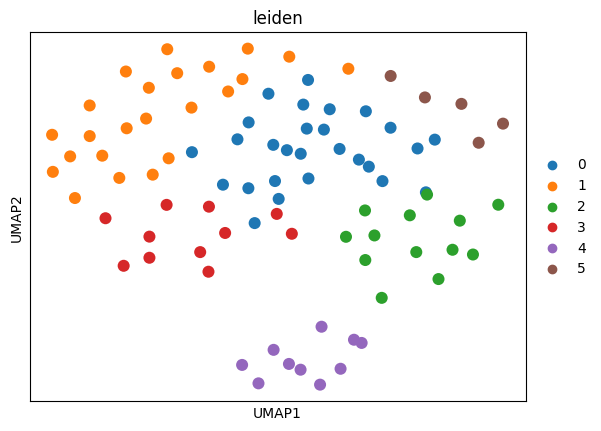

In [56]:
adata.obs.rename(columns={"Asthma": "Asthma_status"}, inplace=True)
sc.pl.umap(adata, color= ['leiden'], cmap='turbo', size = 300)

In [57]:
adata.obs

,donor,Asthma_status,sex,leiden
0,D081,0,0,1
1,D274,0,1,0
2,D340,0,0,1
3,D360,0,0,1
4,D436,0,1,2
...,...,...,...,...
84,D553,1,0,4
85,D563,1,1,2
86,D594,1,0,4
87,D601,1,1,0


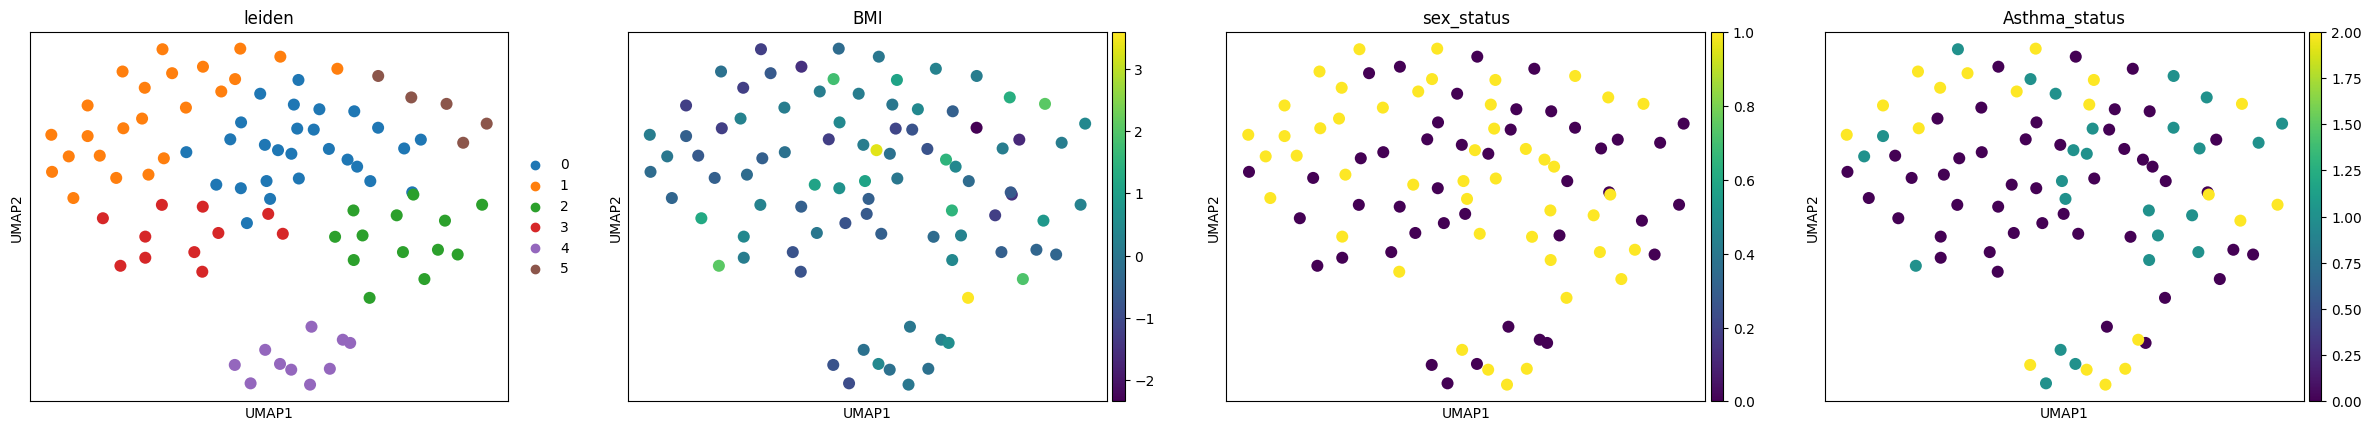

In [58]:
adata.obs.rename(columns={"sex": "sex_status"}, inplace=True)

sc.pl.umap(adata, color=['leiden', 'BMI', 'sex_status', 'Asthma_status'], size = 300)

In [59]:
sc.tl.rank_genes_groups(adata, "leiden", method="wilcoxon")
df = pd.DataFrame(
    {group: adata.uns["rank_genes_groups"]["names"][group] for group in adata.uns["rank_genes_groups"]["names"].dtype.names}
)
df.head(3)

/usr/local/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:461: 

,0,1,2,3,4,5
0,PDGF-AA,SDF-1a+b,LIF,MCP-1,TNFb,IL-1a
1,sCD40L,sex,Eotaxin-3,IL-6,IL-22,IL-1b
2,GROa,Asthma,MCP-2,MDC,MIP-1a,IL-17A


In [60]:
result = adata.uns["rank_genes_groups"]
groups = result["names"].dtype.names

celltype = {'celltype': []}
cluster_to_genes = {}
for group in groups:
    top_genes = result["names"][group][:3]
    cluster_to_genes[group] = f"{':'.join(top_genes)} ({group})"

celltype['celltype'] = [cluster_to_genes[leiden] for leiden in adata.obs['leiden']]
adata.obs["celltype"] = celltype['celltype']

print(adata.obs[["leiden", "celltype"]].head())

  leiden                 celltype
0      1  SDF-1a+b:sex:Asthma (1)
1      0  PDGF-AA:sCD40L:GROa (0)
2      1  SDF-1a+b:sex:Asthma (1)
3      1  SDF-1a+b:sex:Asthma (1)
4      2  LIF:Eotaxin-3:MCP-2 (2)


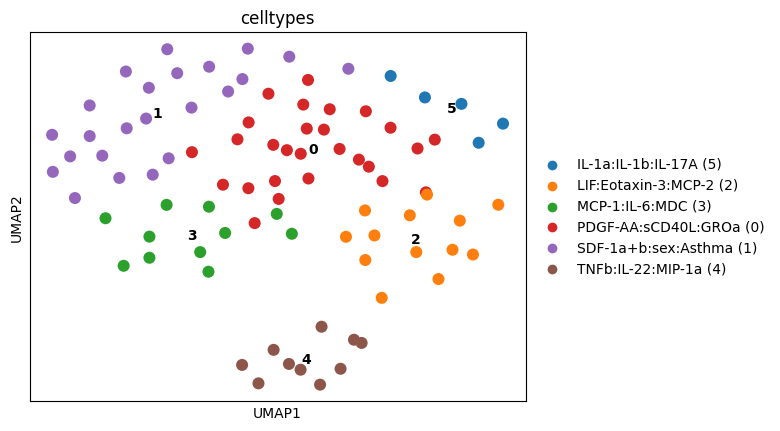

In [61]:
import scanpy as sc
import matplotlib.pyplot as plt

sc.pl.umap(
    adata,
    color=['celltype'],
    cmap='turbo',
    title = 'celltypes',
    show=False,  
    size = 300 
)

ax = plt.gca() 
for cluster in adata.obs['leiden'].cat.categories:
    cluster_mask = adata.obs['leiden'] == cluster
    cluster_coords = adata.obsm['X_umap'][cluster_mask]
    x, y = cluster_coords[:, 0].mean(), cluster_coords[:, 1].mean()
    ax.text(x, y, cluster, color='black', fontsize=10, weight='bold', ha='center', va='center')

plt.show()

In [62]:
cluster_1 = adata[adata.obs['leiden'] == '1']
cluster_1.obs

,donor,Asthma_status,sex_status,leiden,celltype
0,D081,0,0,1,SDF-1a+b:sex:Asthma (1)
2,D340,0,0,1,SDF-1a+b:sex:Asthma (1)
3,D360,0,0,1,SDF-1a+b:sex:Asthma (1)
6,D441,0,0,1,SDF-1a+b:sex:Asthma (1)
7,D447,0,1,1,SDF-1a+b:sex:Asthma (1)
11,D467,0,1,1,SDF-1a+b:sex:Asthma (1)
20,D533,0,0,1,SDF-1a+b:sex:Asthma (1)
30,D556,0,0,1,SDF-1a+b:sex:Asthma (1)
35,D575,0,1,1,SDF-1a+b:sex:Asthma (1)
38,D588,0,1,1,SDF-1a+b:sex:Asthma (1)


/var/folders/66/xf6391m10_1_0gt7tbm34_7r0000gn/T/ipykernel_17286/2923877415.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="sex_status", data=cluster_1.obs, ax=axes[0], palette="coolwarm")
/var/folders/66/xf6391m10_1_0gt7tbm34_7r0000gn/T/ipykernel_17286/2923877415.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Asthma_status", data=cluster_1.obs, ax=axes[1], palette="viridis")


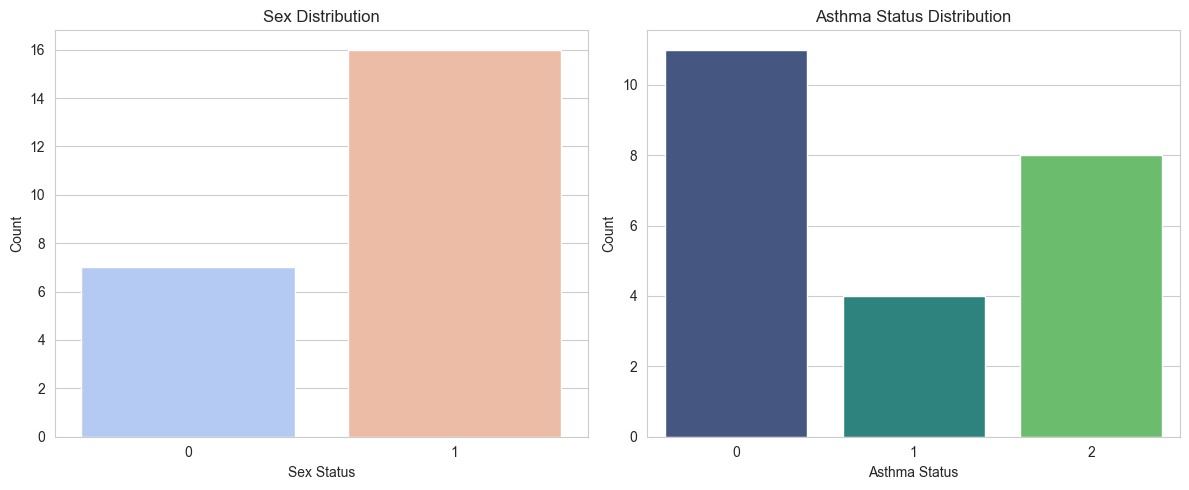

In [63]:
# Set style
sns.set_style("whitegrid")

# Create subplots for better visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot sex distribution
sns.countplot(x="sex_status", data=cluster_1.obs, ax=axes[0], palette="coolwarm")
axes[0].set_title("Sex Distribution")
axes[0].set_xlabel("Sex Status")
axes[0].set_ylabel("Count")

# Plot Asthma distribution
sns.countplot(x="Asthma_status", data=cluster_1.obs, ax=axes[1], palette="viridis")
axes[1].set_title("Asthma Status Distribution")
axes[1].set_xlabel("Asthma Status")
axes[1].set_ylabel("Count")

# Show the plots
plt.tight_layout()
plt.show()

/var/folders/66/xf6391m10_1_0gt7tbm34_7r0000gn/T/ipykernel_17286/892507697.py:4: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  cluster_1.obs['donor'] = cluster_1.obs['donor'].astype("category")


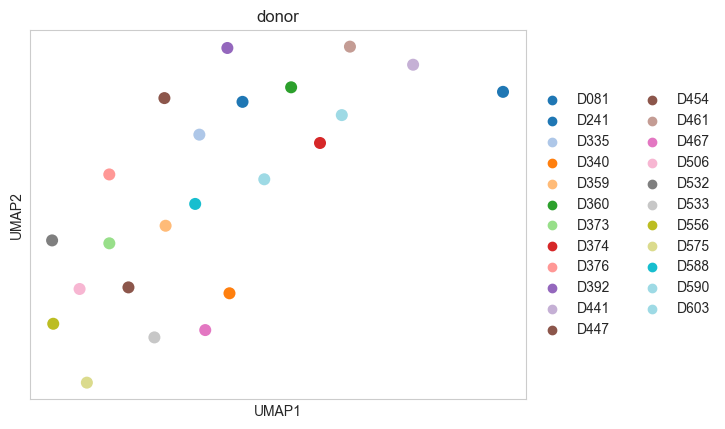

In [64]:
import pandas as pd

# Ensure 'donor' is a categorical variable
cluster_1.obs['donor'] = cluster_1.obs['donor'].astype("category")

# Now plot the UMAP
sc.pl.umap(cluster_1, color=['donor'], palette='tab20', size=300)


## unsupervised

In [65]:
df = pd.read_excel('stat test_01APR25.xlsx')
df['sex'] = df['sex'].apply(lambda x: 0 if x == 'MALE' else 1)
df['Asthma'] = df['Asthma'].apply(lambda x: 2 if x == 'Fatal' else (1 if x == 'History' else 0))
#only include the columns age, asthma, bmi, donor, and sex
df_demographic = df[['age', 'BMI', 'Asthma', 'sex']]

In [66]:
#make unsupervised clusters of rows in df_demographic
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=0).fit(df_demographic)
df_demographic['cluster'] = kmeans.labels_

/usr/local/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/var/folders/66/xf6391m10_1_0gt7tbm34_7r0000gn/T/ipykernel_17286/1620018720.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_demographic['cluster'] = kmeans.labels_


In [67]:
df_demographic

,age,BMI,Asthma,sex,cluster
0,43,31,0,0,2
1,14,23,0,1,0
2,23,25,0,0,0
3,16,18,0,0,0
4,62,27,0,1,1
...,...,...,...,...,...
84,60,22,1,0,1
85,30,32,1,1,2
86,30,32,1,0,2
87,63,25,1,1,1


In [68]:
#sort by age
df_demographic = df_demographic.sort_values(by='age', ascending=True)
df_demographic

,age,BMI,Asthma,sex,cluster
75,6,12,1,0,0
72,9,20,1,1,0
1,14,23,0,1,0
9,15,27,0,0,0
44,15,17,0,0,0
...,...,...,...,...,...
45,64,35,2,0,1
17,68,23,0,1,1
33,71,30,0,0,1
52,71,29,2,1,1


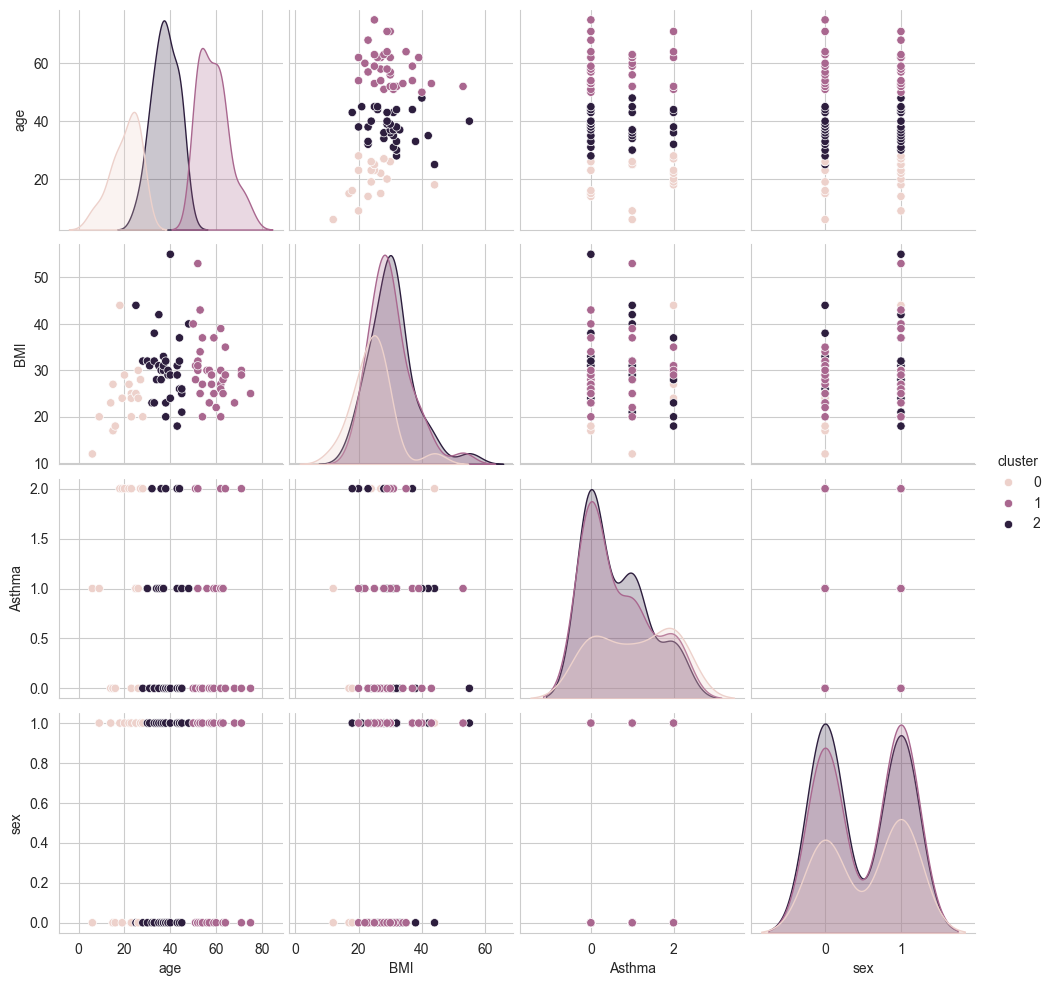

In [69]:
#visualize clusters
sns.pairplot(df_demographic, hue='cluster')

In [70]:
df_demographic['donor'] = df.donor
df_demographic

,age,BMI,Asthma,sex,cluster,donor
75,6,12,1,0,0,D446
72,9,20,1,1,0,D392
1,14,23,0,1,0,D274
9,15,27,0,0,0,D465
44,15,17,0,0,0,D624
...,...,...,...,...,...,...
45,64,35,2,0,1,D220
17,68,23,0,1,1,D525
33,71,30,0,0,1,D562
52,71,29,2,1,1,D450


## asthmatics

In [311]:
df = pd.read_excel('stat test_01APR25.xlsx')
df['sex'] = df['sex'].apply(lambda x: 0 if x == 'MALE' else 1)

In [312]:
df_asthmatics = df[(df['age'] >= 40)]
df_asthmatics.head()

,donor,Asthma,sex,age,BMI,EGF,Eotaxin,FGF-2,FLT-3L,Fractalkine,...,LIF,MCP-2,MCP-4,MIP-1d,SCF,SDF-1a+b,TARC,TPO,TRAIL,TSLP
0,D081,Control,0,43,31,29.94,8.43,815.67,4.41,203.81,...,9.34,17.17,15.98,851.07,2.44,739.39,0.27,12.21,1.44,0.67
4,D436,Control,1,62,27,168.24,11.12,77.87,5.97,29.90,...,19.09,33.44,33.58,2326.79,20.00,1796.22,55.72,342.37,9.57,5.80
5,D439,Control,1,62,26,56.67,20.63,627.14,14.64,148.41,...,209.10,40.64,36.14,3720.55,57.84,2611.31,9.86,3214.11,12.45,45.72
6,D441,Control,0,40,29,21.48,8.34,77.87,4.21,130.80,...,17.33,7.67,6.87,2931.56,2.44,1288.44,0.24,12.21,2.44,8.19
7,D447,Control,1,40,24,20.85,14.11,108.06,4.41,76.67,...,3.54,15.80,1.70,5325.62,2.44,4651.12,9.46,600.16,1.44,0.15


In [313]:
df_asthmatics = df_asthmatics.reset_index(drop=True)
df_asthmatics.head()

,donor,Asthma,sex,age,BMI,EGF,Eotaxin,FGF-2,FLT-3L,Fractalkine,...,LIF,MCP-2,MCP-4,MIP-1d,SCF,SDF-1a+b,TARC,TPO,TRAIL,TSLP
0,D081,Control,0,43,31,29.94,8.43,815.67,4.41,203.81,...,9.34,17.17,15.98,851.07,2.44,739.39,0.27,12.21,1.44,0.67
1,D436,Control,1,62,27,168.24,11.12,77.87,5.97,29.90,...,19.09,33.44,33.58,2326.79,20.00,1796.22,55.72,342.37,9.57,5.80
2,D439,Control,1,62,26,56.67,20.63,627.14,14.64,148.41,...,209.10,40.64,36.14,3720.55,57.84,2611.31,9.86,3214.11,12.45,45.72
3,D441,Control,0,40,29,21.48,8.34,77.87,4.21,130.80,...,17.33,7.67,6.87,2931.56,2.44,1288.44,0.24,12.21,2.44,8.19
4,D447,Control,1,40,24,20.85,14.11,108.06,4.41,76.67,...,3.54,15.80,1.70,5325.62,2.44,4651.12,9.46,600.16,1.44,0.15


In [314]:
exclude_cols = ['Asthma', 'donor', 'sex']
df_asthmatics.loc[:, ~df_asthmatics.columns.isin(exclude_cols)] = scaler.fit_transform(df_asthmatics.loc[:, ~df_asthmatics.columns.isin(exclude_cols)])

/var/folders/66/xf6391m10_1_0gt7tbm34_7r0000gn/T/ipykernel_17286/3288554101.py:2: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[-1.30341342  0.86408785  0.86408785 -1.64565046 -1.64565046 -0.04854426
  0.52185081  0.40777179 -0.16262328  1.54856194  2.34711503 -1.07525539
 -1.1893344  -0.16262328  0.29369278 -0.50486032  1.09224588 -0.04854426
 -0.04854426 -0.16262328  1.89079898 -1.07525539 -1.64565046  0.29369278
 -1.1893344  -0.3907813   0.40777179  1.09224588  0.86408785  1.89079898
 -1.1893344  -0.3907813  -0.27670229 -0.27670229 -1.30341342 -1.07525539
 -0.27670229  0.86408785  0.52185081  0.86408785  0.17961377 -0.73301835
  0.97816687 -1.30341342 -0.27670229  0.63592982  0.97816687]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_asthmatics.loc[:, ~df_asthmatics.columns.isin(exclude_cols)] = scaler.fit_transform(df_asthmatics.loc[:, ~df_asthmatics.columns.isin(e

In [315]:
pca = PCA(n_components=0.9)

X = df_asthmatics.drop(['Asthma', 'donor', 'sex'], axis=1)
X = pca.fit_transform(X)

pca_columns = [f'PC{i+1}' for i in range(X.shape[1])]
X_df= pd.DataFrame(X, columns=pca_columns)

X_df = pd.concat([X_df, df_asthmatics[['Asthma', 'donor','sex']]], axis=1)
X_df['sex'] = X_df['sex'].apply(lambda x: 'Male' if x == 0 else 'Female')

In [316]:
X_df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC15,PC16,PC17,PC18,PC19,PC20,PC21,Asthma,donor,sex
0,0.063685,2.467604,-5.799090,2.887823,-0.633774,-0.596291,-0.937011,2.397174,1.752695,2.445550,...,-1.350454,-1.077037,-0.241774,0.669572,-0.265432,2.816906,0.976689,Control,D081,Male
1,0.119292,0.015200,-0.066215,-0.437019,4.306764,1.245263,3.587147,1.227830,-1.657315,-1.034695,...,0.119239,0.961289,1.193426,-1.576758,0.257908,1.113324,-1.137268,Control,D436,Female
2,9.302953,-1.539967,-3.777138,1.389191,3.559195,-1.271279,0.953580,-0.827876,0.714472,1.450240,...,1.485190,0.321368,-1.600801,0.311901,-0.047511,0.342030,-0.424136,Control,D439,Female
3,-2.164759,0.207073,-4.975874,1.011238,0.801010,0.140139,-0.033923,0.047703,1.099839,1.637108,...,-0.753604,0.255231,0.253919,0.355061,1.169812,-1.782201,1.689534,Control,D441,Male
4,-3.339340,-0.412489,-1.639387,0.251810,-0.358683,0.054361,0.631230,-1.134637,0.660353,1.978684,...,0.004682,-0.073596,-0.121921,-0.240481,0.062131,-1.153424,-0.700490,Control,D447,Female


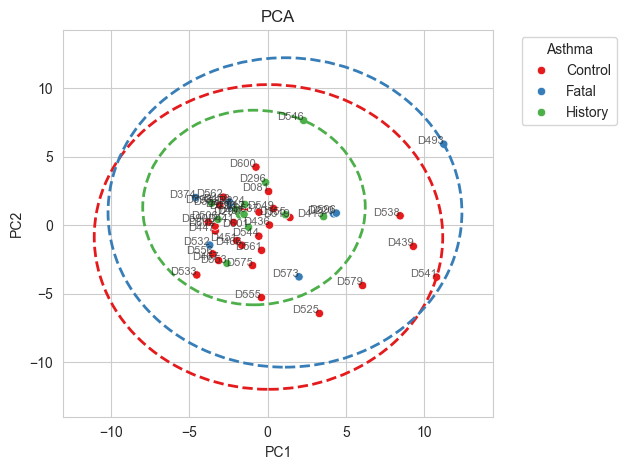

In [317]:
palette = sns.color_palette('Set1', n_colors=X_df['Asthma'].nunique())
sex_categories = X_df['Asthma'].unique()
color_dict = dict(zip(sex_categories, palette))

# Create scatter plot with mapped colors
scatter = sns.scatterplot(x='PC1', y='PC2', data=X_df, hue='Asthma', palette=color_dict)

# Annotate each point with its 'donor' value
for i, row in X_df.iterrows():
    plt.text(row['PC1'], row['PC2'], str(row['donor']), fontsize=8, ha='right', alpha=0.7)

# Compute centroids and plot circles
all_x, all_y = [], []  # Store all points for axis limit adjustment
for sex_group in sex_categories:
    subset = X_df[X_df['Asthma'] == sex_group]
    if not subset.empty:
        # Compute centroid
        centroid_x, centroid_y = subset[['PC1', 'PC2']].mean()
        
        # Compute max Euclidean distance for circle radius
        max_distance = np.max(np.sqrt((subset['PC1'] - centroid_x) ** 2 + (subset['PC2'] - centroid_y) ** 2))
        
        # Draw a circle with the same color as the points
        circle = plt.Circle((centroid_x, centroid_y), max_distance, color=color_dict[sex_group], fill=False, linestyle='--', linewidth=2)
        plt.gca().add_patch(circle)

        # Store values to adjust axis limits
        all_x.extend(subset['PC1'])
        all_y.extend(subset['PC2'])
        all_x.append(centroid_x + max_distance)
        all_x.append(centroid_x - max_distance)
        all_y.append(centroid_y + max_distance)
        all_y.append(centroid_y - max_distance)

# Labels and title
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA')

# Expand axis limits to fit the circles
plt.xlim(min(all_x) - 2, max(all_x) + 2)
plt.ylim(min(all_y) - 2, max(all_y) + 2)

# Adjust legend positioning
plt.legend(title='Asthma', bbox_to_anchor=(1.05, 1), loc='upper left')

# Final layout adjustment
plt.tight_layout()
plt.show()

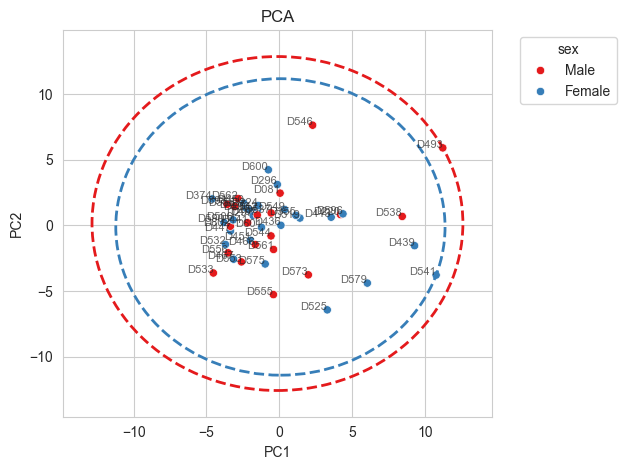

In [318]:
palette = sns.color_palette('Set1', n_colors=X_df['sex'].nunique())
sex_categories = X_df['sex'].unique()
color_dict = dict(zip(sex_categories, palette))

# Create scatter plot with mapped colors
scatter = sns.scatterplot(x='PC1', y='PC2', data=X_df, hue='sex', palette=color_dict)

# Annotate each point with its 'donor' value
for i, row in X_df.iterrows():
    plt.text(row['PC1'], row['PC2'], str(row['donor']), fontsize=8, ha='right', alpha=0.7)

# Compute centroids and plot circles
all_x, all_y = [], []  # Store all points for axis limit adjustment
for sex_group in sex_categories:
    subset = X_df[X_df['sex'] == sex_group]
    if not subset.empty:
        # Compute centroid
        centroid_x, centroid_y = subset[['PC1', 'PC2']].mean()
        
        # Compute max Euclidean distance for circle radius
        max_distance = np.max(np.sqrt((subset['PC1'] - centroid_x) ** 2 + (subset['PC2'] - centroid_y) ** 2))
        
        # Draw a circle with the same color as the points
        circle = plt.Circle((centroid_x, centroid_y), max_distance, color=color_dict[sex_group], fill=False, linestyle='--', linewidth=2)
        plt.gca().add_patch(circle)

        # Store values to adjust axis limits
        all_x.extend(subset['PC1'])
        all_y.extend(subset['PC2'])
        all_x.append(centroid_x + max_distance)
        all_x.append(centroid_x - max_distance)
        all_y.append(centroid_y + max_distance)
        all_y.append(centroid_y - max_distance)

# Labels and title
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA')

# Expand axis limits to fit the circles
plt.xlim(min(all_x) - 2, max(all_x) + 2)
plt.ylim(min(all_y) - 2, max(all_y) + 2)

# Adjust legend positioning
plt.legend(title='sex', bbox_to_anchor=(1.05, 1), loc='upper left')

# Final layout adjustment
plt.tight_layout()
plt.show()

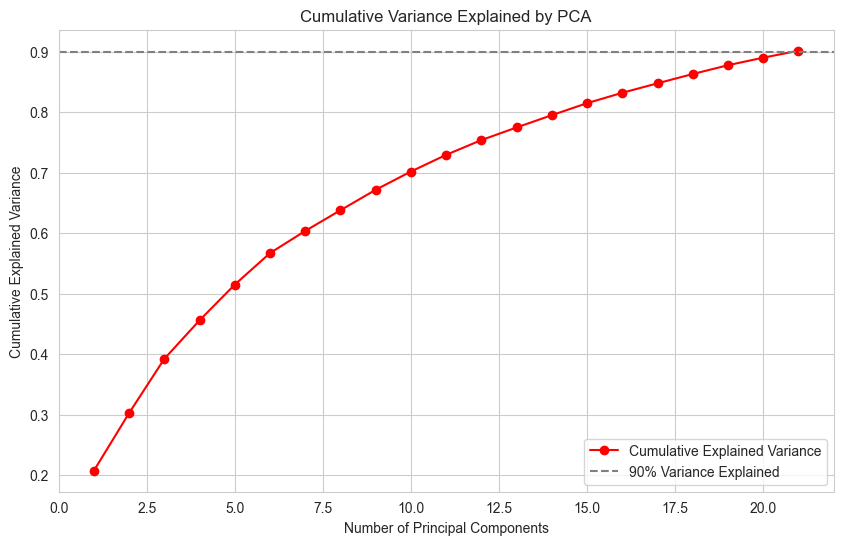

In [319]:
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(10, 6))
plt.plot(np.arange(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='-', color='r', label='Cumulative Explained Variance')
plt.axhline(y=0.9, color='gray', linestyle='--', label='90% Variance Explained')  # 90% threshold line
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("Cumulative Variance Explained by PCA")
plt.grid(True)
plt.legend()
plt.show()

In [320]:
features = df_asthmatics.drop(['Asthma', 'donor', 'sex'], axis=1).columns
pca_loadings = pd.DataFrame(pca.components_, columns=features, index=[f'PC{i+1}' for i in range(pca.n_components_)])
top_5_features = pca_loadings.abs().apply(lambda x: x.nlargest(5).index.tolist(), axis=1)
print(top_5_features)

PC1                   [IL-33, TPO, IL-9, IL-16, TSLP]
PC2             [IL-22, M-CSF, IL-1a, PDGF-AA, IL-1b]
PC3          [IP-10, MIG_CXCL9, IL-5, I-309, PDGF-AA]
PC4     [PDGF-AB_BB, TNFb, MIP-1a, ENA-78, MIG_CXCL9]
PC5             [IL-15, IL-17E_IL-25, EGF, IL-2, age]
PC6             [IL-4, TRAIL, CTACK, IL-12p70, IL-1b]
PC7      [MDC, Eotaxin, IL-8, Eotaxin-2, Fractalkine]
PC8             [RANTES, IL-18, M-CSF, IL-5, Eotaxin]
PC9              [IL-5, FGF-2, IP-10, 6CKine, GM-CSF]
PC10                 [IL-27, MIP-1b, G-CSF, age, EGF]
PC11          [SDF-1a+b, MIP-1d, IL-1RA, FGF-2, IL-6]
PC12        [Eotaxin, MCP-1, VEGF-A, MCP-4, IL-12p40]
PC13            [IL-3, BMI, Eotaxin-2, BCA-1, FLT-3L]
PC14                  [IL-10, TNFa, IL-9, BMI, CTACK]
PC15      [sCD40L, MIP-1b, IL-10, FGF-2, Fractalkine]
PC16              [MCP-3, IL-8, IL-13, MIP-1b, IL-18]
PC17              [ENA-78, MCP-3, MIP-1a, BMI, IL-18]
PC18       [BMI, MIP-1b, IL-27, Fractalkine, PDGF-AA]
PC19            [TARC, IL-13

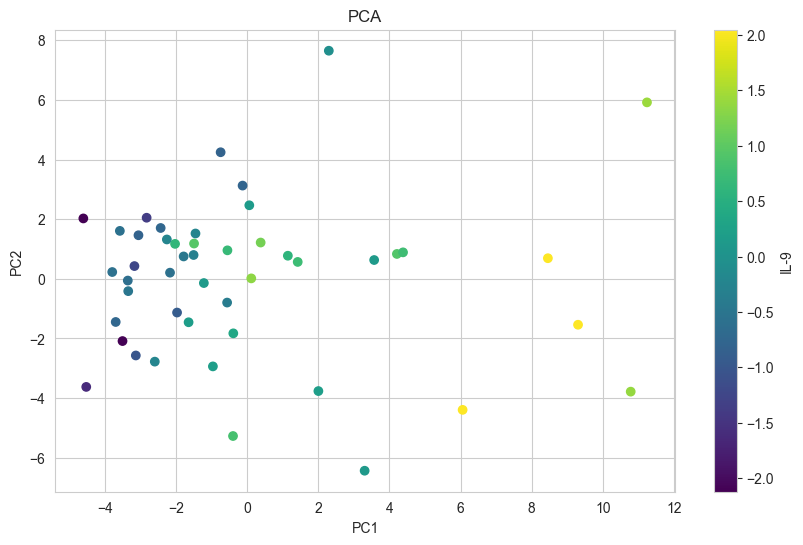

In [321]:
plt.figure(figsize=(10,6))
plt.scatter(X[:, 0], X[:, 1], c=df_asthmatics['IL-9'], cmap='viridis')
plt.colorbar(label='IL-9')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA')
plt.show()

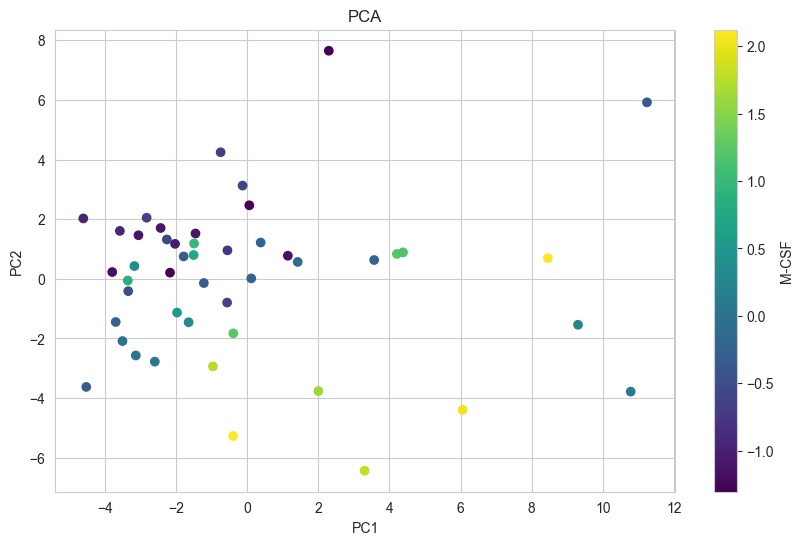

In [322]:
plt.figure(figsize=(10,6))
plt.scatter(X[:, 0], X[:, 1], c=df_asthmatics['M-CSF'], cmap='viridis')
plt.colorbar(label='M-CSF')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA')
plt.show()

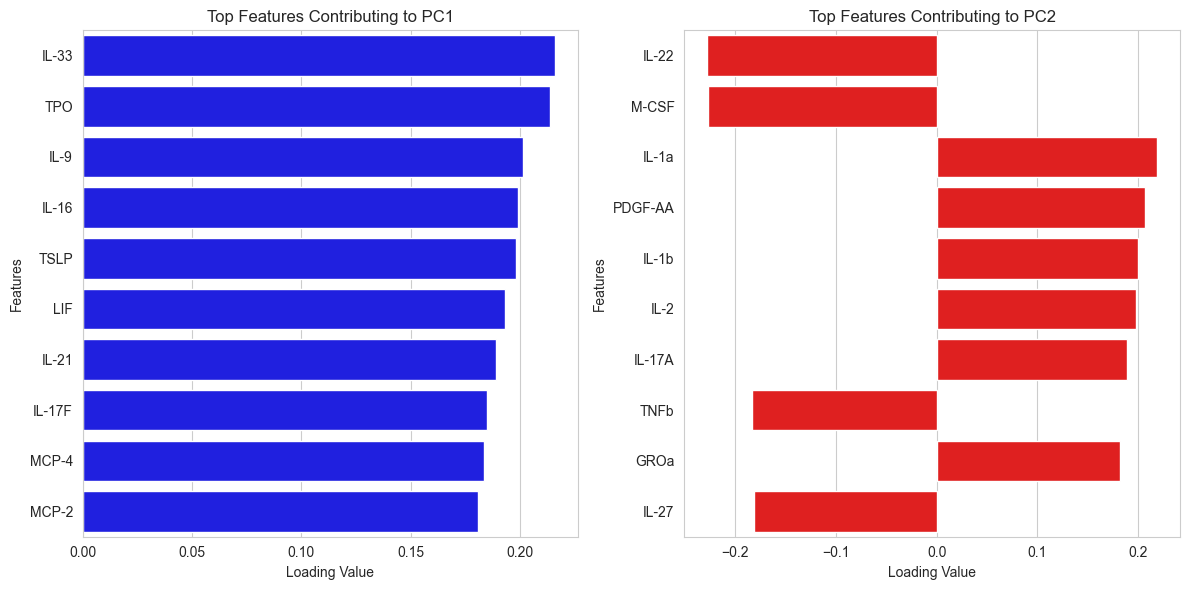

In [323]:
# Extract PC1 and PC2 loadings
pc1_loadings = pca_loadings.loc["PC1"].sort_values(key=abs, ascending=False)
pc2_loadings = pca_loadings.loc["PC2"].sort_values(key=abs, ascending=False)

# Create subplots
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# PC1 plot
sns.barplot(x=pc1_loadings.values[:10], y=pc1_loadings.index[:10], ax=axes[0], color='blue')
axes[0].set_title("Top Features Contributing to PC1")
axes[0].set_xlabel("Loading Value")
axes[0].set_ylabel("Features")

# PC2 plot
sns.barplot(x=pc2_loadings.values[:10], y=pc2_loadings.index[:10], ax=axes[1], color='red')
axes[1].set_title("Top Features Contributing to PC2")
axes[1].set_xlabel("Loading Value")
axes[1].set_ylabel("Features")

plt.tight_layout()
plt.show()

In [324]:
df_asthmatics = df_asthmatics.drop('donor', axis = 1)
X = df_asthmatics.drop('Asthma', axis = 1)
X.head()

,sex,age,BMI,EGF,Eotaxin,FGF-2,FLT-3L,Fractalkine,G-CSF,GM-CSF,...,LIF,MCP-2,MCP-4,MIP-1d,SCF,SDF-1a+b,TARC,TPO,TRAIL,TSLP
0,0,-1.303413,0.124940,-0.645695,-1.093424,2.727894,-0.853357,1.309094,-0.642433,3.129364,...,-0.318027,-0.462780,0.353325,-1.462732,-0.722536,-1.681855,-1.105169,-0.597644,-0.804165,-0.523943
1,1,0.864088,-0.408893,1.519972,-0.844850,-0.807973,-0.537771,-1.375542,-0.873645,-0.607137,...,-0.121853,1.340722,1.883294,-0.599256,-0.190432,-0.769152,1.426528,-0.257914,-0.054191,-0.032509
2,1,0.864088,-0.542351,-0.227125,0.033935,1.824374,1.216161,0.453888,-0.360059,-0.007130,...,3.701233,2.138830,2.105835,0.216264,0.956197,-0.065221,-0.667315,2.697071,0.211483,3.791667
3,0,-1.645650,-0.141977,-0.778172,-1.101740,-0.807973,-0.893817,0.182044,-0.926528,-0.607137,...,-0.157265,-1.515839,-0.438608,-0.245391,-0.722536,-1.207683,-1.106538,-0.597644,-0.711917,0.196443
4,1,-1.645650,-0.809267,-0.788037,-0.568555,-0.663289,-0.853357,-0.653557,-0.984577,-0.607137,...,-0.434726,-0.614642,-0.888037,1.155426,-0.722536,1.696408,-0.685578,0.007349,-0.804165,-0.573757


In [325]:
X_train, X_test, y_train, y_test = train_test_split(X, df_asthmatics['Asthma'], test_size=0.25, random_state=0)

In [326]:
model = RandomForestClassifier(n_estimators=100, random_state=0)
model.fit(X_train, y_train)

scores = cross_val_score(model, X, df_asthmatics['Asthma'], cv=5)
print("Cross-validation scores:", scores)
print("Mean cross-validation score:", scores.mean())

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Cross-validation scores: [0.7        0.5        0.55555556 0.66666667 0.44444444]
Mean cross-validation score: 0.5733333333333333
Accuracy: 0.4166666666666667


In [327]:
importances = model.feature_importances_
importances_df = pd.DataFrame({
    'feature': X.columns,
    'importance': importances
})
importances_df.sort_values(by='importance', ascending=False).head(10)

,feature,importance
32,IL-18,0.054867
14,IL-1b,0.039188
68,SCF,0.032322
58,IL-16,0.031544
13,IL-1a,0.028317
43,PDGF-AA,0.026947
42,MIP-1b,0.026669
47,TGFa,0.026613
5,FGF-2,0.024543
4,Eotaxin,0.024034


In [328]:
y_test

28      Fatal
33      Fatal
30      Fatal
4     Control
18    Control
11    Control
42    History
31      Fatal
22    Control
10    Control
27      Fatal
32      Fatal
Name: Asthma, dtype: object

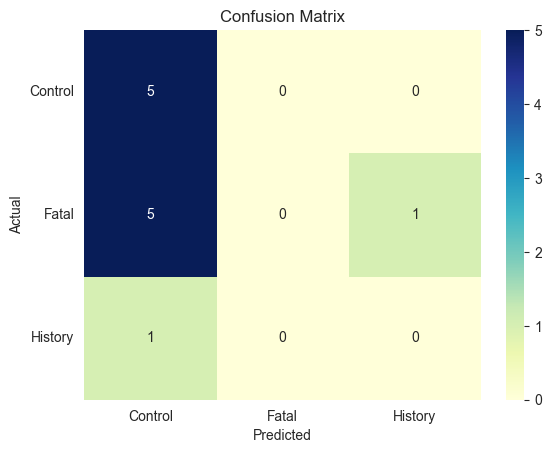

In [329]:
class_names = ['Control', 'Fatal', 'History'] 

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot the confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu')

# Set axis labels and class names
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.xticks(ticks=[0.5, 1.5, 2.5], labels=class_names)
plt.yticks(ticks=[0.5, 1.5, 2.5], labels=class_names, rotation=0)

# Show the plot
plt.show()


In [330]:
df = pd.read_excel('stat test_01APR25.xlsx')
df['sex'] = df['sex'].apply(lambda x: 0 if x == 'MALE' else 1)
#if Asthma == Control, set 0, if Asthma == History, set 1, if Asthma == fatal, set 2
df['Asthma'] = df['Asthma'].apply(lambda x: 2 if x == 'Fatal' else (1 if x == 'History' else 0))
df_asthmatics = df[(df['BMI'] >= 30)]

In [331]:
df_numeric = df_asthmatics.select_dtypes(include=[np.number])
list_metadata = {'donor' : df_asthmatics.donor, 'Asthma' : df_asthmatics.Asthma, 'sex': df_asthmatics.sex}
df_metadata = pd.DataFrame(list_metadata)

In [332]:
adata = sc.AnnData(df_numeric)
df_metadata.index = adata.obs.index
adata.obs['donor'] = df_metadata.donor
adata.obs['Asthma'] = df_metadata.Asthma
adata.obs['sex'] = df_metadata.sex

/usr/local/lib/python3.11/site-packages/anndata/utils.py:304: UserWarning: X converted to numpy array with dtype float64
  warnings.warn(f"{name} converted to numpy array with dtype {arr.dtype}")
/usr/local/lib/python3.11/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


In [333]:
sc.pp.scale(adata, max_value=5)

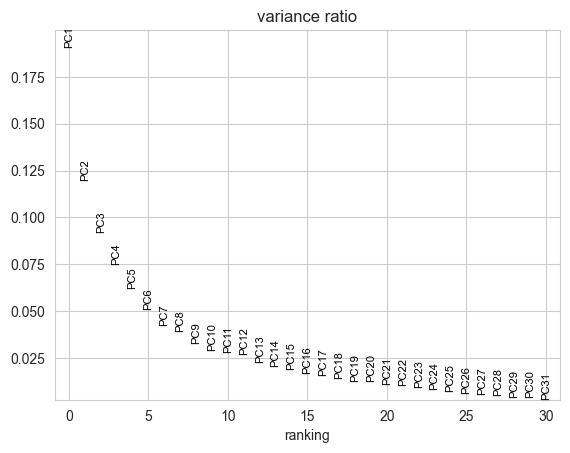

In [334]:
sc.tl.pca(adata, svd_solver="arpack")
sc.pl.pca_variance_ratio(adata, log=False)

/Users/derekmartinez/Library/Python/3.11/lib/python/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8942 (\N{VERTICAL ELLIPSIS}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


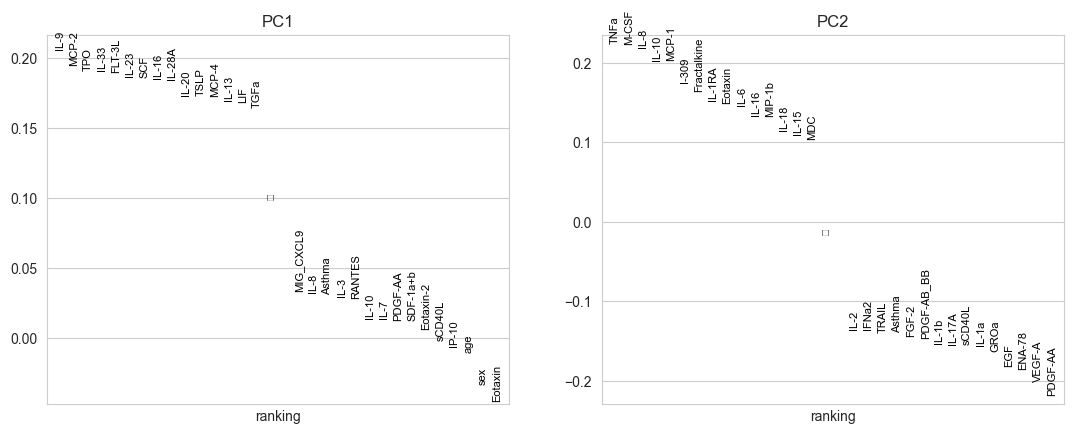

In [335]:
sc.pl.pca_loadings(adata, components = '1,2')

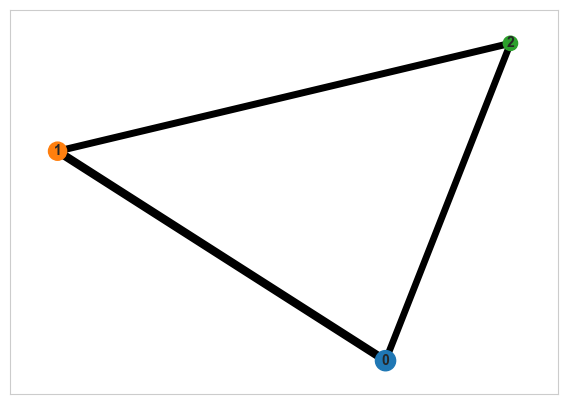

In [336]:
sc.pp.neighbors(adata, n_neighbors=15, n_pcs= 15, random_state=0)
sc.tl.leiden(adata, resolution=0.8, flavor='leidenalg')
sc.tl.paga(adata)
sc.pl.paga(adata)
sc.tl.umap(adata, init_pos='paga', random_state=0)

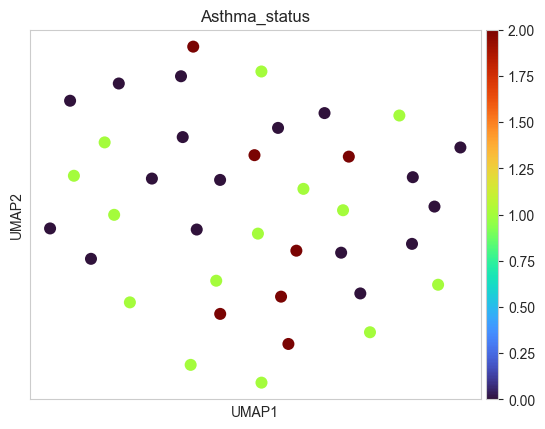

In [337]:
adata.obs.rename(columns={"Asthma": "Asthma_status"}, inplace=True)
sc.pl.umap(adata, color="Asthma_status", cmap='turbo', size=300)

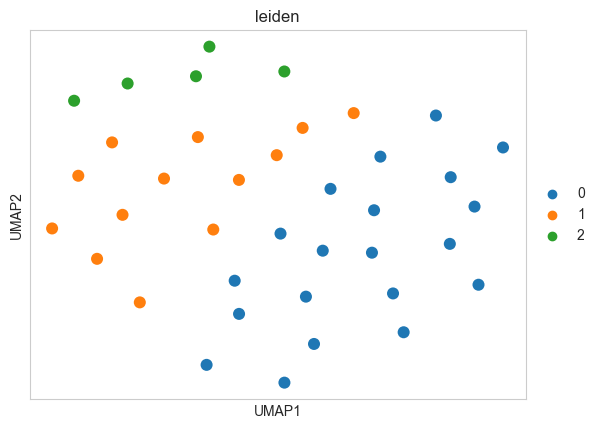

In [338]:
sc.pl.umap(adata, color= ['leiden'], cmap='turbo', size = 300)

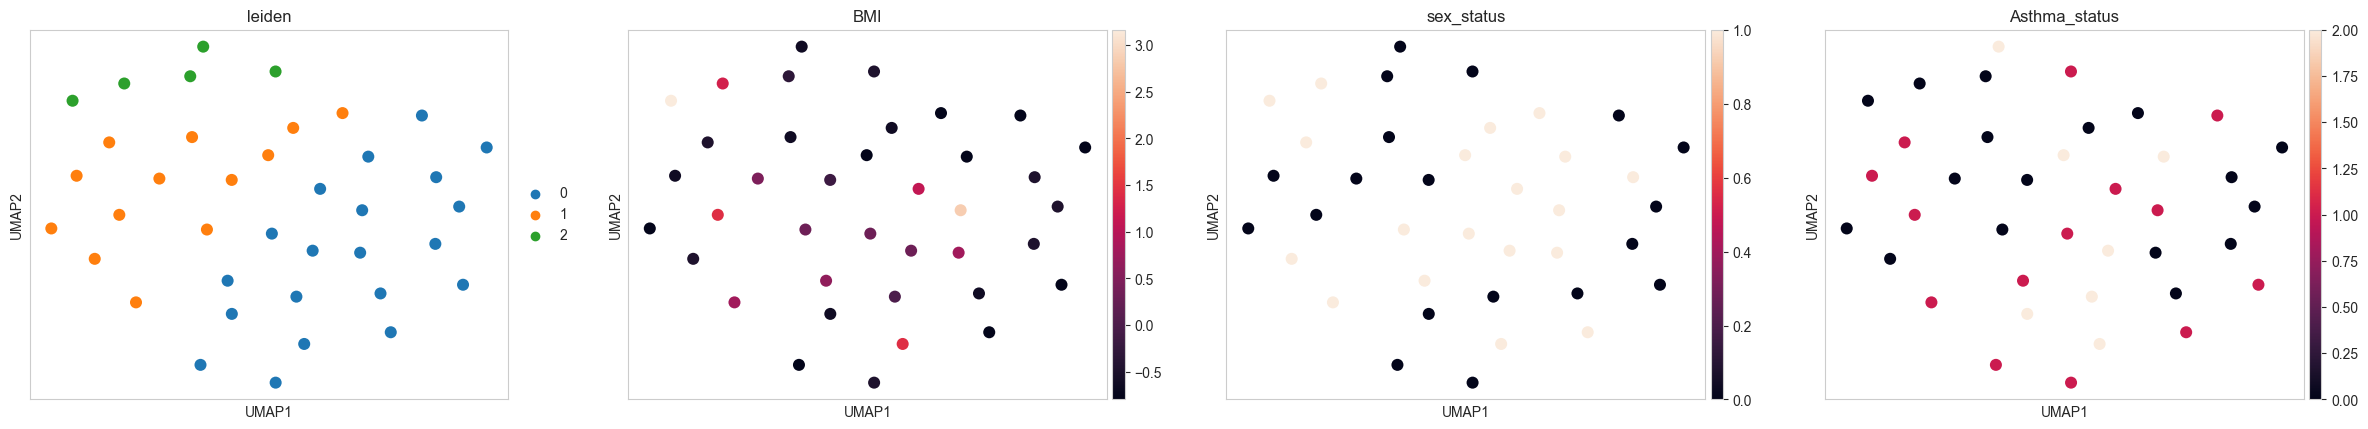

In [339]:
adata.obs.rename(columns={"sex": "sex_status"}, inplace=True)

sc.pl.umap(adata, color=['leiden', 'BMI', 'sex_status', 'Asthma_status'], size = 300)

In [340]:
sc.tl.rank_genes_groups(adata, "leiden", method="wilcoxon")
df = pd.DataFrame(
    {group: adata.uns["rank_genes_groups"]["names"][group] for group in adata.uns["rank_genes_groups"]["names"].dtype.names}
)
df.head(3)

/usr/local/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.11/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


,0,1,2
0,VEGF-A,MCP-1,IL-22
1,PDGF-AA,Eotaxin,TNFb
2,EGF,IL-6,MIP-1a


In [341]:
result = adata.uns["rank_genes_groups"]
groups = result["names"].dtype.names

celltype = {'celltype': []}
cluster_to_genes = {}
for group in groups:
    top_genes = result["names"][group][:3]
    cluster_to_genes[group] = f"{':'.join(top_genes)} ({group})"

celltype['celltype'] = [cluster_to_genes[leiden] for leiden in adata.obs['leiden']]
adata.obs["celltype"] = celltype['celltype']

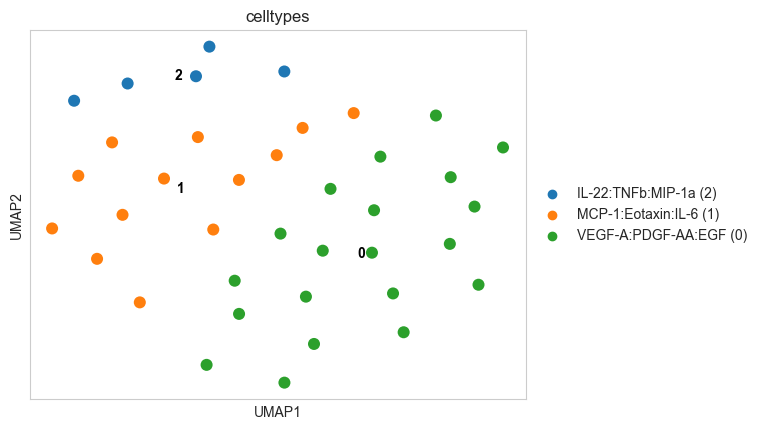

In [342]:
sc.pl.umap(
    adata,
    color=['celltype'],
    cmap='turbo',
    title = 'celltypes',
    show=False,  
    size = 300 
)

ax = plt.gca() 
for cluster in adata.obs['leiden'].cat.categories:
    cluster_mask = adata.obs['leiden'] == cluster
    cluster_coords = adata.obsm['X_umap'][cluster_mask]
    x, y = cluster_coords[:, 0].mean(), cluster_coords[:, 1].mean()
    ax.text(x, y, cluster, color='black', fontsize=10, weight='bold', ha='center', va='center')

plt.show()

In [343]:
cluster_1 = adata[adata.obs['leiden'] == '0']
cluster_1.obs

,donor,Asthma_status,sex_status,leiden,celltype
0,D081,0,0,0,VEGF-A:PDGF-AA:EGF (0)
19,D530,0,0,0,VEGF-A:PDGF-AA:EGF (0)
28,D549,0,1,0,VEGF-A:PDGF-AA:EGF (0)
33,D562,0,0,0,VEGF-A:PDGF-AA:EGF (0)
36,D577,0,0,0,VEGF-A:PDGF-AA:EGF (0)
41,D600,0,1,0,VEGF-A:PDGF-AA:EGF (0)
45,D220,2,0,0,VEGF-A:PDGF-AA:EGF (0)
49,D374,2,1,0,VEGF-A:PDGF-AA:EGF (0)
51,D403,2,1,0,VEGF-A:PDGF-AA:EGF (0)
55,D477,2,1,0,VEGF-A:PDGF-AA:EGF (0)


In [344]:
donors = cluster_1.obs['donor'].unique()  # get unique donor names
donors_1 = df_asthmatics[df_asthmatics['donor'].isin(donors)]


/var/folders/66/xf6391m10_1_0gt7tbm34_7r0000gn/T/ipykernel_17286/2353495862.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="sex_status", data=cluster_1.obs, ax=axes[0], palette="coolwarm")
/var/folders/66/xf6391m10_1_0gt7tbm34_7r0000gn/T/ipykernel_17286/2353495862.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="Asthma_status", data=cluster_1.obs, ax=axes[1], palette="viridis")


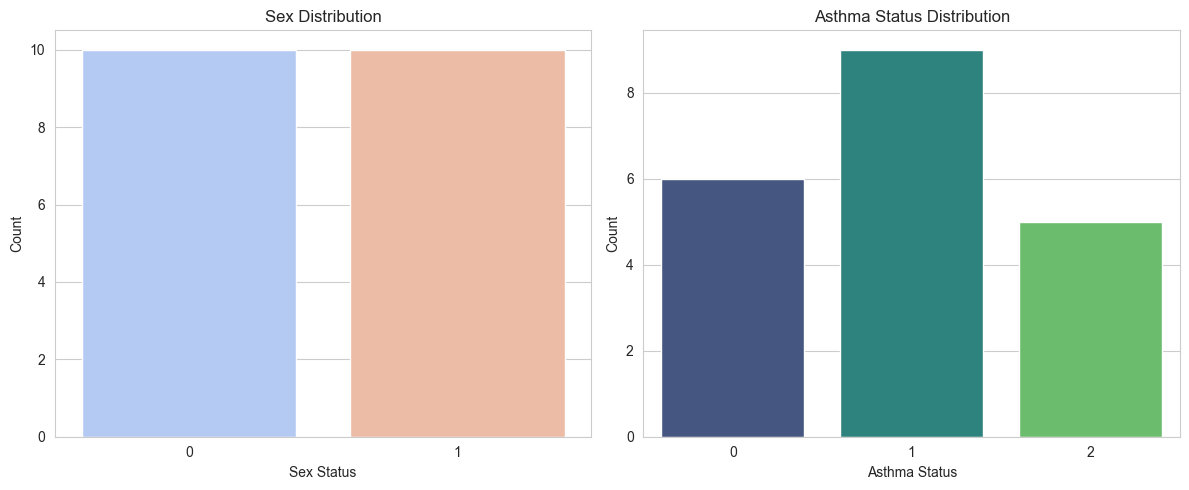

In [345]:
# Set style
sns.set_style("whitegrid")

# Create subplots for better visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))


sns.countplot(x="sex_status", data=cluster_1.obs, ax=axes[0], palette="coolwarm")
axes[0].set_title("Sex Distribution")
axes[0].set_xlabel("Sex Status")
axes[0].set_ylabel("Count")

# #plot age distribution
# sns.histplot(donors_1['age'], bins=15, ax=axes[0], color="skyblue")
# axes[0].set_title("Age Distribution")
# axes[0].set_xlabel("Age")


# Plot Asthma distribution
sns.countplot(x="Asthma_status", data=cluster_1.obs, ax=axes[1], palette="viridis")
axes[1].set_title("Asthma Status Distribution")
axes[1].set_xlabel("Asthma Status")
axes[1].set_ylabel("Count")

# Show the plots
plt.tight_layout()
plt.show()

/var/folders/66/xf6391m10_1_0gt7tbm34_7r0000gn/T/ipykernel_17286/1588386394.py:2: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  cluster_1.obs['donor'] = cluster_1.obs['donor'].astype("category")


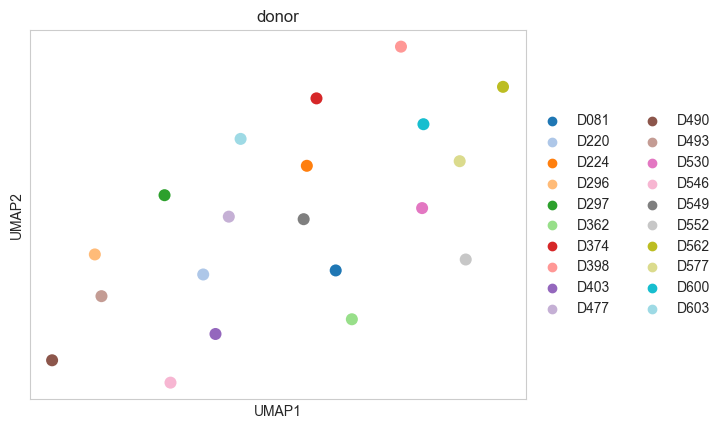

In [346]:
# Ensure 'donor' is a categorical variable
cluster_1.obs['donor'] = cluster_1.obs['donor'].astype("category")

# Now plot the UMAP
sc.pl.umap(cluster_1, color=['donor'], palette='tab20', size=300)


In [347]:
df = pd.read_excel('stat test_01APR25.xlsx')
df['sex'] = df['sex'].apply(lambda x: 0 if x == 'MALE' else 1)
df['Asthma'] = df['Asthma'].apply(lambda x: 2 if x == 'Fatal' else (1 if x == 'History' else 0))
#only include the columns age, asthma, bmi, donor, and sex
df_demographic = df[['age', 'BMI', 'Asthma', 'sex']]
#select asthmatics
df_asthmatics = df_demographic[(df_demographic['BMI'] >= 30)]

In [348]:
kmeans = KMeans(n_clusters=3, random_state=0).fit(df_asthmatics)
df_asthmatics['cluster'] = kmeans.labels_

/usr/local/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)
/var/folders/66/xf6391m10_1_0gt7tbm34_7r0000gn/T/ipykernel_17286/229284137.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_asthmatics['cluster'] = kmeans.labels_


In [349]:
df_asthmatics

,age,BMI,Asthma,sex,cluster
0,43,31,0,0,1
8,54,37,0,1,0
12,33,38,0,0,1
14,33,32,0,1,1
18,39,30,0,0,1
19,28,32,0,0,1
25,53,43,0,1,2
26,35,31,0,0,1
28,50,40,0,1,2
32,53,34,0,0,0


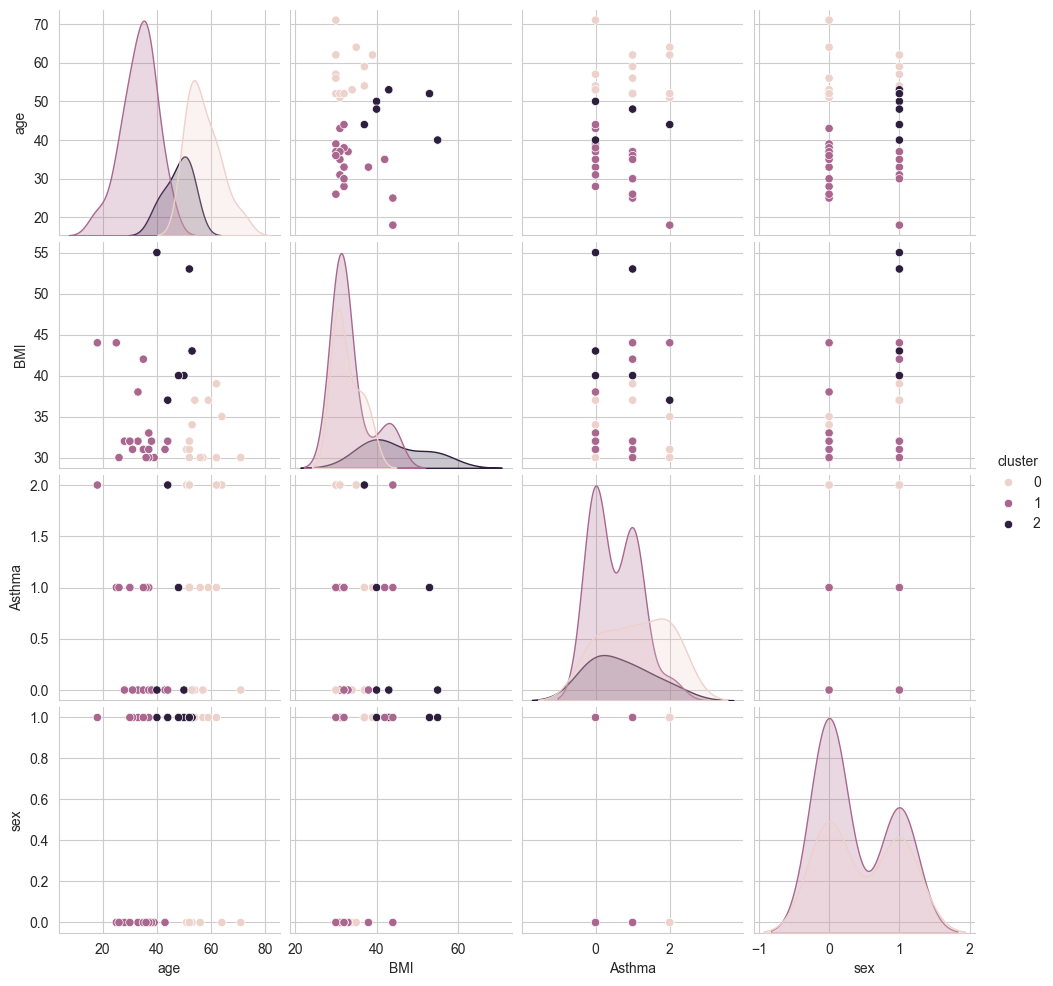

In [350]:
sns.pairplot(df_asthmatics, hue='cluster')